Data source: https://www.frontiersin.org/journals/microbiology/articles/10.3389/fmicb.2022.1050574/full

In [ ]:
# Please run the following code to install all neccesary libraries, 
# unless you have already installed them using conda recipe: conda_recipes/r_libraries.yaml.

# R Library Installation Script
# Install required packages for microbiome analysis

# Install BiocManager if not already installed (needed for Bioconductor packages)
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

# Install Bioconductor packages
BiocManager::install("phyloseq")
BiocManager::install("GUniFrac")

# Install CRAN packages
install.packages("vegan")
install.packages("ape")
install.packages("ggplot2")
install.packages("ggpubr")
install.packages("PMA")
install.packages("reshape2")
install.packages("tidyr")
install.packages("phytools")

# Note: 'parallel' is part of base R and doesn't need to be installed

# Verify installations by loading libraries
cat("\n=== Verifying installations ===\n")
libraries <- c("phyloseq", "vegan", "ape", "ggplot2", "ggpubr", 
               "PMA", "parallel", "reshape2", "tidyr", "GUniFrac", "phytools")

for (lib in libraries) {
  if (require(lib, character.only = TRUE, quietly = TRUE)) {
    cat(sprintf("✓ %s loaded successfully\n", lib))
  } else {
    cat(sprintf("✗ %s failed to load\n", lib))
  }
}

cat("\nInstallation complete!\n")

In [ ]:
# load libararies
library(phyloseq)
library(vegan)
library(ape)
library(ggplot2)
library(ggpubr)
library(PMA)
library(parallel)
library(reshape2)
library(tidyr)
library(GUniFrac)
library(phytools)

Loading required package: maps


Attaching package: ‘phytools’


The following object is masked from ‘package:vegan’:

    scores




### Load data

In [ ]:
data_path <- '../../data/PRJNA880162/processed/phyloseq'
dir.create("../../data/data_analysis")

In [100]:
ps_microbiome <- readRDS(file.path(data_path, 'input_data_16S/phyloseq.rds'))
ps_mycobiome <- readRDS(file.path(data_path, 'input_data_ITS/phyloseq.rds'))
ps_microbiome
ps_mycobiome

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 14691 taxa and 384 samples ]
sample_data() Sample Data:       [ 384 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 14691 taxa by 7 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 6159 taxa and 404 samples ]
sample_data() Sample Data:       [ 404 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 6159 taxa by 7 taxonomic ranks ]

### Agglomerate by genus

In [101]:
head(otu_table(ps_microbiome))

,GTGCCAGCAGCCGCGGTAATACGTAGGGTGCAAGCGTTATCCGGAATTATTGGGCGTAAAGGGCTCGTAGGCGGTTCGTCGCGTCCGGTGTGAAAGTCCATCGCTTAACGGTGGATCCGCGCCGGGTACGGGCGGGCTTGAGTGCGGTAGGGGAGACTGGAATTCCCGGTGTAACGGTGGAATGTGTAGATATCGGGAAGAACACCAATGGCGAAGGCAGGTCTCTGGGCCGTTACTGACGCTGAGGAGCGAAAGCGTGGGGAGCGAACAGGATTAGAAACCCCAGTAGTCC,CGTCGGCAGCGTCAGATGTGTATAAGAGACAGGTGCCAGCAGCCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGAAACCCCAGTAGTCCCTGTCTCTTATACACATCTCCGAGCCCACGAG,GTGCCAGCAGCCGCGGTAATACGTAGGGTGCAAGCGTTATCCGGAATTATTGGGCGTAAAGGGCTCGTAGGCGGTTCGTCGCGTCCGGTGTGAAAGTCCATCGCTTAACGGTGGATCCGCGCCGGGTACGGGCGGGCTTGAGTGCGGTAGGGGAGACTGGAATTCCCGGTGTAACGGTGGAATGTGTAGATATCGGGAAGAACACCAATGGCGAAGGCAGGTCTCTGGGCCGTTACTGACGCTGAGGAGCGAAAGCGTGGGGAGCGAACAGGATTAGAAACCCCTGTAGTCC,CGTCGGCAGCGTCAGATGTGTATAAGAGACAGGTGCCAGCAGCCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGAAACCCCGGTAGTCCCTGTCTCTTATACACATCTCCGAGCCCACGAG,GTGCCAGCAGCCGCGGTAATACGTAGGGTGCAAGCGTTATCCGGAATTATTGGGCGTAAAGGGCTCGTAGGCGGTTCGTCGCGTCCGGTGTGAAAGTCCATCGCTTAACGGTGGATCCGCGCCGGGTACGGGCGGGCTTGAGTGCGGTAGGGGAGACTGGAATTCCCGGTGTAACGGTGGAATGTGTAGATATCGGGAAGAACACCAATGGCGAAGGCAGGTCTCTGGGCCGTTACTGACGCTGAGGAGCGAAAGCGTGGGGAGCGAACAGGATTAGAAACCCTAGTAGTCC,GTGCCAGCAGCCGCGGTAATACGTAGGGTGCAAGCGTTATCCGGAATTATTGGGCGTAAAGGGCTCGTAGGCGGTTCGTCGCGTCCGGTGTGAAAGTCCATCGCTTAACGGTGGATCCGCGCCGGGTACGGGCGGGCTTGAGTGCGGTAGGGGAGACTGGAATTCCCGGTGTAACGGTGGAATGTGTAGATATCGGGAAGAACACCAATGGCGAAGGCAGGTCTCTGGGCCGTTACTGACGCTGAGGAGCGAAAGCGTGGGGAGCGAACAGGATTAGAAACCCCGGTAGTCC,CGTCGGCAGCGTCAGATGTGTATAAGAGACAGGTGCCAGCAGCCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGAAACCCCTGTAGTCCCTGTCTCTTATACACATCTCCGAGCCCACGAG,GTGCCAGCAGCCGCGGTAATACGTAGGGTGCAAGCGTTATCCGGAATTATTGGGCGTAAAGGGCTCGTAGGCGGTTCGTCGCGTCCGGTGTGAAAGTCCATCGCTTAACGGTGGATCCGCGCCGGGTACGGGCGGGCTTGAGTGCGGTAGGGGAGACTGGAATTCCCGGTGTAACGGTGGAATGTGTAGATATCGGGAAGAACACCAATGGCGAAGGCAGGTCTCTGGGCCGTTACTGACGCTGAGGAGCGAAAGCGTGGGGAGCGAACAGGATTAGAAACCCTTGTAGTCC,CGTCGGCAGCGTCAGATGTGTATAAGAGACAGGTGCCAGCAGCCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGAAACCCTAGTAGTCCCTGTCTCTTATACACATCTCCGAGCCCACGAG,CGTCGGCAGCGTCAGATGTGTATAAGAGACAGGTGCCAGCAGCCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGAAACCCGAGTAGTCCCTGTCTCTTATACACATCTCCGAGCCCACGAG,⋯,TTTCCCTCCTCCTCTTTCCTCCTCCGGGGTCTCGCGTTGCTCGGAATCACTGGGCGTAAAGGGCGCGTAGGCGGCGTTTTAAGTCGGGGGTGAAAGCCTGTGGCTCAACCACAGAATGGCCTTCGATACTGGGACGCTTGAGTATGGTAGAGGTTGGTGGAACTGCGAGTGTAGAGGTGAAATTCGTAGATATTCGCAAGAACACCGGTGGCGAAGGCGGCCAACTGGACCATTACTGACGCTGAGGCGCGAAAGCGTGGGGAGCAAACAGGATTAGAAACCCGAGTAGTCC,GTGCCAGCCGCCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGCTCGTAGGTGGTTTGTCGCGTCGTCTGTGAAATCCCGGGGCTTAACTCCGGGCGTGCAGGCGATACGGGCATAACTGGAGTGCTGTAGGGGAGACTGGAATTCCTGGTGTAGCGGTGAAATGCGCAGATATCAGGAGGAACACCGATGGCGAAGGCAGGTCTCTGGGCAGTAACTGACGCTGAGGAGCGAAAGCATGGGTAGCGAACAGGATTAGATACCCTTGTAGTCC,GTGCCAGCCGCCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGCTTGTAGGCGGTTTGTCGCGTCTGCTGTGAAAGGCCGGGGCTTAACCCCGTGTATTGCAGTGGGTACGGGCAGACTAGAGTGCAGTAGGGGAGACTGGAATTCCTGGTGTAGCGGTGGAATGCGCAGATATCAGGAGGAACACCGATGGCGAAGGCAGGTCTCTGGGCTGTAACTGACGCTGAGAAGCGAAAGCATGGGGAGCGAACAGGATTAGATACCCTGGTAGTCC,GTGCCAGCCGCCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGCTCGTAGGTGGTTTGTCGCGTCGTCTGTGAAATCCCGGGGCTTAACTCCGGGCGTGCAGGCGATACGGGCATAACTGGAGTGCTGTAGGGGAGACTGGAATTCCTGGTGTAGCGGTGAAATGCGCAGATATCAGGAGGAACACCGATGGCGAAGGCAGGTCTCTGGGCAGTAACTGACGCTGAGGAGCGAAAGCATGGGTAGCGAACAGGATTAGAAACCCTAGTAGTCC,GTGCCAGCCG

In [102]:
head(tax_table(ps_microbiome))

,Kingdom,Phylum,Class,Order,Family,Genus,Species
GTGCCAGCAGCCGCGGTAATACGTAGGGTGCAAGCGTTATCCGGAATTATTGGGCGTAAAGGGCTCGTAGGCGGTTCGTCGCGTCCGGTGTGAAAGTCCATCGCTTAACGGTGGATCCGCGCCGGGTACGGGCGGGCTTGAGTGCGGTAGGGGAGACTGGAATTCCCGGTGTAACGGTGGAATGTGTAGATATCGGGAAGAACACCAATGGCGAAGGCAGGTCTCTGGGCCGTTACTGACGCTGAGGAGCGAAAGCGTGGGGAGCGAACAGGATTAGAAACCCCAGTAGTCC,Bacteria,Actinomycetota,Actinobacteria,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium,NA
CGTCGGCAGCGTCAGATGTGTATAAGAGACAGGTGCCAGCAGCCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGAAACCCCAGTAGTCCCTGTCTCTTATACACATCTCCGAGCCCACGAG,Eukaryota,NA,NA,NA,NA,NA,NA
GTGCCAGCAGCCGCGGTAATACGTAGGGTGCAAGCGTTATCCGGAATTATTGGGCGTAAAGGGCTCGTAGGCGGTTCGTCGCGTCCGGTGTGAAAGTCCATCGCTTAACGGTGGATCCGCGCCGGGTACGGGCGGGCTTGAGTGCGGTAGGGGAGACTGGAATTCCCGGTGTAACGGTGGAATGTGTAGATATCGGGAAGAACACCAATGGCGAAGGCAGGTCTCTGGGCCGTTACTGACGCTGAGGAGCGAAAGCGTGGGGAGCGAACAGGATTAGAAACCCCTGTAGTCC,Bacteria,Actinomycetota,Actinobacteria,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium,NA
CGTCGGCAGCGTCAGATGTGTATAAGAGACAGGTGCCAGCAGCCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGAAACCCCGGTAGTCCCTGTCTCTTATACACATCTCCGAGCCCACGAG,Eukaryota,NA,NA,NA,NA,NA,NA
GTGCCAGCAGCCGCGGTAATACGTAGGGTGCAAGCGTTATCCGGAATTATTGGGCGTAAAGGGCTCGTAGGCGGTTCGTCGCGTCCGGTGTGAAAGTCCATCGCTTAACGGTGGATCCGCGCCGGGTACGGGCGGGCTTGAGTGCGGTAGGGGAGACTGGAATTCCCGGTGTAACGGTGGAATGTGTAGATATCGGGAAGAACACCAATGGCGAAGGCAGGTCTCTGGGCCGTTACTGACGCTGAGGAGCGAAAGCGTGGGGAGCGAACAGGATTAGAAACCCTAGTAGTCC,Bacteria,Actinomycetota,Actinobacteria,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium,NA
GTGCCAGCAGCCGCGGTAATACGTAGGGTGCAAGCGTTATCCGGAATTATTGGGCGTAAAGGGCTCGTAGGCGGTTCGTCGCGTCCGGTGTGAAAGTCCATCGCTTAACGGTGGATCCGCGCCGGGTACGGGCGGGCTTGAGTGCGGTAGGGGAGACTGGAATTCCCGGTGTAACGGTGGAATGTGTAGATATCGGGAAGAACACCAATGGCGAAGGCAGGTCTCTGGGCCGTTACTGACGCTGAGGAGCGAAAGCGTGGGGAGCGAACAGGATTAGAAACCCCGGTAGTCC,Bacteria,Actinomycetota,Actinobacteria,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium,NA


In [103]:
ps_microbiome <- tax_glom(ps_microbiome, 'Genus')
ps_mycobiome <- tax_glom(ps_mycobiome, 'Genus')
ps_microbiome
ps_mycobiome

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 632 taxa and 384 samples ]
sample_data() Sample Data:       [ 384 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 632 taxa by 7 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 140 taxa and 404 samples ]
sample_data() Sample Data:       [ 404 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 140 taxa by 7 taxonomic ranks ]

In [104]:
taxa_names(ps_microbiome) <- tax_table(ps_microbiome)[, 'Genus']
taxa_names(ps_mycobiome) <- tax_table(ps_mycobiome)[, 'Genus']

In [105]:
head(otu_table(ps_microbiome))

,Bifidobacterium,Escherichia-Shigella,Staphylococcus,Streptococcus,Bacteroides,Enterobacter,Clostridium,Klebsiella,Veillonella,[Ruminococcus] gnavus group,⋯,Rhodomicrobium,Mixta,Larkinella,Stenoxybacter,FFCH7168,Sphaerimonospora,Pseudoflavonifractor,Sorangium,Parafilimonas,Okibacterium
SRR21564107,0,0,7067,664,20,1454,0,996,25,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564108,9320,3266,0,441,147,0,0,0,5446,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564109,12863,0,101,128,0,2707,457,471,346,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564110,78,0,1102,645,58,0,0,0,85,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564111,9932,0,0,448,9984,0,0,0,52,737,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564112,10451,42,32,1516,12724,0,8198,0,17,0,⋯,0,0,0,0,0,0,0,0,0,0


In [106]:
otu_table(ps_microbiome)[rowSums(otu_table(ps_microbiome)) == 0, ]
otu_table(ps_mycobiome)[rowSums(otu_table(ps_mycobiome)) == 0, ]

ps_microbiome <- prune_samples(rowSums(otu_table(ps_microbiome)) > 0, ps_microbiome)
ps_mycobiome <- prune_samples(rowSums(otu_table(ps_mycobiome)) > 0, ps_mycobiome)
ps_microbiome
ps_mycobiome

,Bifidobacterium,Escherichia-Shigella,Staphylococcus,Streptococcus,Bacteroides,Enterobacter,Clostridium,Klebsiella,Veillonella,[Ruminococcus] gnavus group,⋯,Rhodomicrobium,Mixta,Larkinella,Stenoxybacter,FFCH7168,Sphaerimonospora,Pseudoflavonifractor,Sorangium,Parafilimonas,Okibacterium
SRR21564181,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564255,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564330,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


,g__Sarocladium,g__Malassezia,g__Candida,g__Paecilomyces,g__Cladosporium,g__Fusarium,g__Alternaria,g__Pertusaria,g__Aspergillus,g__Yarrowia,⋯,g__Nothophoma,g__Pyrenophora,g__Metschnikowia,g__Septoriella,g__Parastagonospora,g__Helgardiomyces,g__Limonomyces,g__Microdochium,g__Phaeosphaeria,g__Sphaerellopsis
SRR21564713,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564717,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564718,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564719,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564724,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564730,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564732,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564733,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564739,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564746,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 632 taxa and 381 samples ]
sample_data() Sample Data:       [ 381 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 632 taxa by 7 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 140 taxa and 356 samples ]
sample_data() Sample Data:       [ 356 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 140 taxa by 7 taxonomic ranks ]

### Convert to relative abundance

In [107]:
ps_microbiome <- transform_sample_counts(ps_microbiome, function(x) {x / sum(x)})
ps_mycobiome <- transform_sample_counts(ps_mycobiome, function(x) {x / sum(x)})

In [108]:
head(otu_table(ps_microbiome))

,Bifidobacterium,Escherichia-Shigella,Staphylococcus,Streptococcus,Bacteroides,Enterobacter,Clostridium,Klebsiella,Veillonella,[Ruminococcus] gnavus group,⋯,Rhodomicrobium,Mixta,Larkinella,Stenoxybacter,FFCH7168,Sphaerimonospora,Pseudoflavonifractor,Sorangium,Parafilimonas,Okibacterium
SRR21564107,0.000000000,0.000000000,0.5437408633,0.051088713,0.001538817,0.1118720,0.00000000,0.07663307,0.0019235208,0.00000000,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564108,0.471755416,0.165316866,0.0000000000,0.022322332,0.007440777,0.0000000,0.00000000,0.00000000,0.2756630897,0.00000000,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564109,0.699684508,0.000000000,0.0054939077,0.006962576,0.000000000,0.1472476,0.02485857,0.02562010,0.0188207137,0.00000000,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564110,0.002527871,0.000000000,0.0357142857,0.020903552,0.001879699,0.0000000,0.00000000,0.00000000,0.0027547317,0.00000000,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564111,0.358336039,0.000000000,0.0000000000,0.016163365,0.360212144,0.0000000,0.00000000,0.00000000,0.0018761049,0.02659018,⋯,0,0,0,0,0,0,0,0,0,0
SRR21564112,0.302989012,0.001217638,0.0009277245,0.043950947,0.368886441,0.0000000,0.23767141,0.00000000,0.0004928536,0.00000000,⋯,0,0,0,0,0,0,0,0,0,0


### Subset same samples

In [109]:
clean_metadata <- function(metadata_preselected){
    metadata_modified <- metadata_preselected
    colnames(metadata_modified) <- c('age', 'sample_source', 'diet', 
                                                'sex', 'subject_id')
    metadata_modified['age'] <- paste0('t', metadata_preselected[['host.age']], 'month')
    metadata_modified[metadata_preselected[['host.age']] == 6, 'age'] <- paste0(metadata_modified[metadata_preselected[['host.age']] == 6, 
                                                                                                  'age'], 's')
    metadata_modified['sample_source'] <- gsub('human ', '', metadata_preselected[['host.body.product']])
    metadata_modified['subject_id'] <- paste0('fam#', metadata_modified[['subject_id']])
    metadata_modified['sample_id'] <- paste(metadata_modified[['subject_id']], 
                                        metadata_modified[['age']],
                                        metadata_modified[['sample_source']], sep='_')
    return(metadata_modified)
}

In [110]:
metadata_microbiome <- data.frame(sample_data(ps_microbiome))
metadata_microbiome <- metadata_microbiome[, c('host.age', 'host.body.product', 
                                     'host.diet', 'host.sex', 
                                     'host.subject.id')]
metadata_microbiome <- clean_metadata(metadata_microbiome)
sample_data(ps_microbiome) <- metadata_microbiome
sample_names(ps_microbiome) <- metadata_microbiome[['sample_id']]

In [111]:
metadata_mycobiome <- data.frame(sample_data(ps_mycobiome))
metadata_mycobiome <- metadata_mycobiome[, c('host.age', 'host.body.product', 
                                     'host.diet', 'host.sex', 
                                     'host.subject.id')]
metadata_mycobiome <- clean_metadata(metadata_mycobiome)
sample_data(ps_mycobiome) <- metadata_mycobiome
sample_names(ps_mycobiome) <- metadata_mycobiome[['sample_id']]

In [112]:
sample_ids_microbiome <- metadata_microbiome[['sample_id']]
sample_ids_mycobiome <- metadata_mycobiome[['sample_id']]
sample_ids <- intersect(sample_ids_microbiome, sample_ids_mycobiome)

In [113]:
ps_microbiome <- prune_samples(sample_ids, ps_microbiome)
ps_mycobiome <- prune_samples(sample_ids, ps_mycobiome)
# ensure samples order
otu_table(ps_microbiome) <- otu_table(ps_microbiome)[sample_ids, ]
otu_table(ps_mycobiome) <- otu_table(ps_mycobiome)[sample_ids, ]
ps_microbiome
ps_mycobiome

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 632 taxa and 335 samples ]
sample_data() Sample Data:       [ 335 samples by 6 sample variables ]
tax_table()   Taxonomy Table:    [ 632 taxa by 7 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 140 taxa and 335 samples ]
sample_data() Sample Data:       [ 335 samples by 6 sample variables ]
tax_table()   Taxonomy Table:    [ 140 taxa by 7 taxonomic ranks ]

In [ ]:
saveRDS(ps_microbiome, '../../data/data_analysis/ps_microbiome.processed.rds')
saveRDS(ps_mycobiome, '../../data/data_analysis/ps_mycobiome.processed.rds')

# PCoA based on Bray-Curtis distance

In [114]:
otu_data_microbiome <- data.frame(otu_table(ps_microbiome))
# compute bray-curtis pairwise distances
bray_curtis_dist_microbiome <- vegdist(otu_data_microbiome, method = "bray")
# compute pcoa
pcoa_res_microbiome <- pcoa(bray_curtis_dist_microbiome)

# reformat the result table for plotting with ggplot
pcoa_coordinates_microbiome <- data.frame(pcoa_res_microbiome$vectors)[, c('Axis.1', 'Axis.2')]
colnames(pcoa_coordinates_microbiome) <- c('PCoA1', 'PCoA2')
pcoa_coordinates_microbiome <- cbind(pcoa_coordinates_microbiome, sample_data(ps_microbiome))
pcoa_coordinates_microbiome$sample_type <- 'Microbiome'


In [115]:
otu_data_mycobiome <- data.frame(otu_table(ps_mycobiome))
# compute bray-curtis pairwise distances
bray_curtis_dist_mycobiome <- vegdist(otu_data_mycobiome, method = "bray")
# compute pcoa
pcoa_res_mycobiome <- pcoa(bray_curtis_dist_mycobiome)

# reformat the result table for plotting with ggplot
pcoa_coordinates_mycobiome <- data.frame(pcoa_res_mycobiome$vectors)[, c('Axis.1', 'Axis.2')]
colnames(pcoa_coordinates_mycobiome) <- c('PCoA1', 'PCoA2')
pcoa_coordinates_mycobiome <- cbind(pcoa_coordinates_mycobiome, sample_data(ps_mycobiome))
pcoa_coordinates_mycobiome$sample_type <- 'Mycobiome'

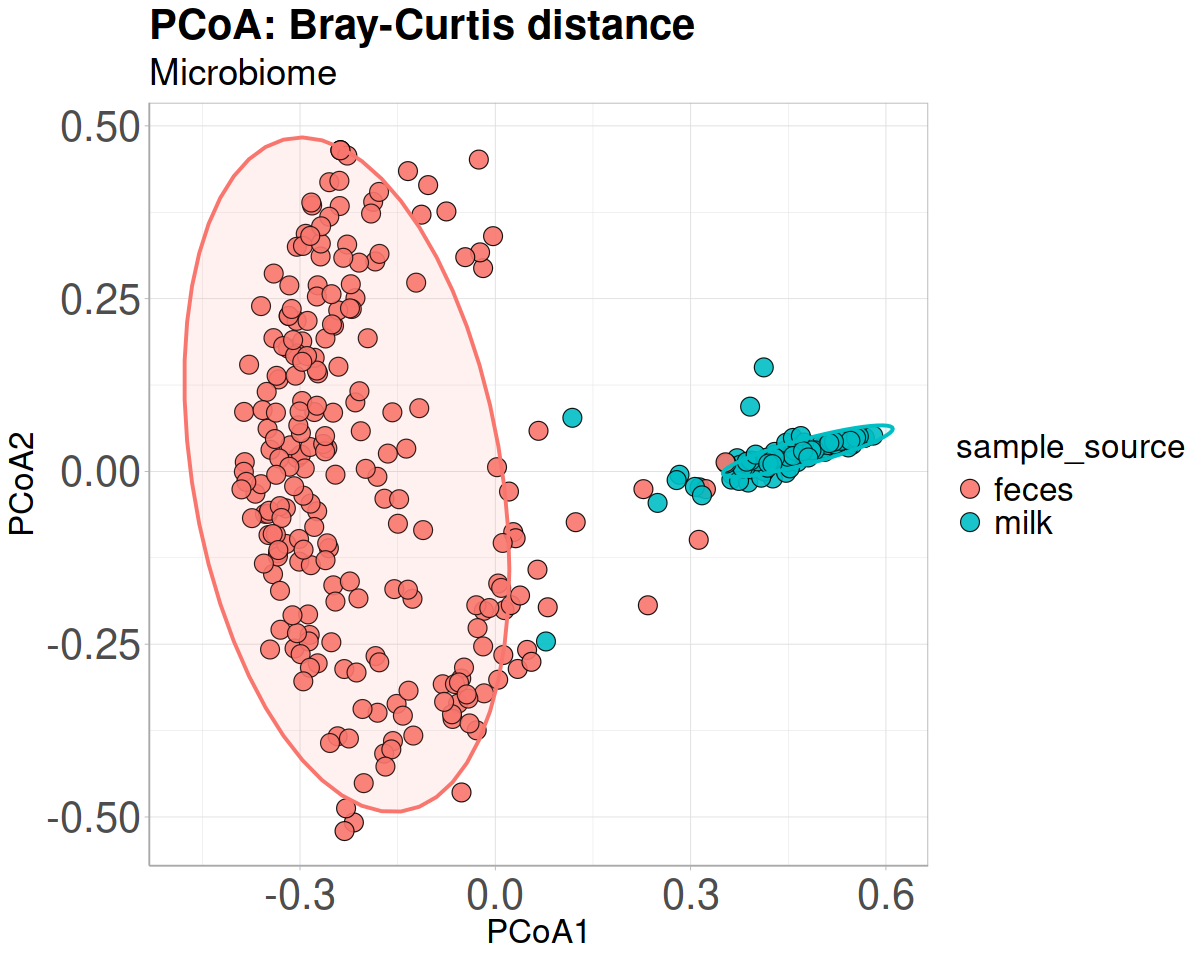

In [116]:
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_microbiome <- ggplot(data = pcoa_coordinates_microbiome, aes(x=PCoA1, y=PCoA2)) +
# plot sample values projected on PCoA
      geom_point(aes(fill = sample_source), 
                 size = 5, alpha=0.9, pch=21) +
# plot group circles
      stat_ellipse(geom = "polygon",
                   aes(color = sample_source, 
                       fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
# add titles
      labs(
           title = "PCoA: Bray-Curtis distance", 
           subtitle = "Microbiome") +
# custom plot design
      theme_light() +
      theme(axis.text=element_text(size=25),
            axis.title=element_text(size=20), 
            plot.title=element_text(size=25, face="bold"),
            plot.subtitle=element_text(size=22, face="plain"),
            plot.caption = element_text(face = "italic"),
            axis.text.x.bottom = element_text(size=25, angle=0, face='plain', hjust=0.5, vjust=0.5),
            text = element_text(size = 25), 
            legend.title=element_text(size=20),
            axis.line = element_line(color = "darkgrey"))  
pcoa_braycurtis_microbiome

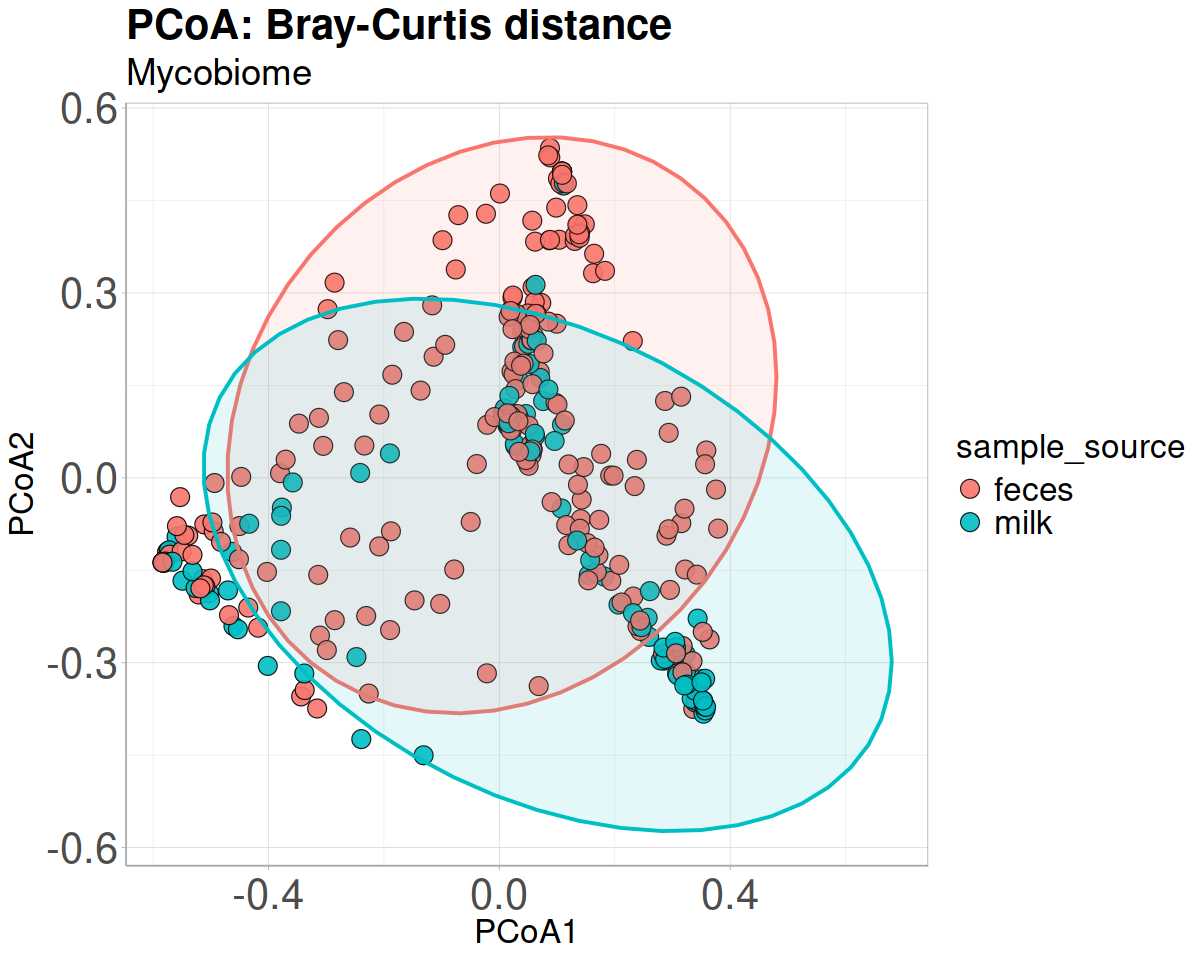

In [117]:
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_mycobiome <- ggplot(data = pcoa_coordinates_mycobiome, aes(x=PCoA1, y=PCoA2)) +
# plot sample values projected on PCoA
      geom_point(aes(fill = sample_source), 
                 size = 5, alpha=0.9, pch=21) +
# plot group circles
      stat_ellipse(geom = "polygon",
                   aes(color = sample_source, 
                       fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
# add titles
      labs(
           title = "PCoA: Bray-Curtis distance", 
           subtitle = "Mycobiome") +
# custom plot design
      theme_light() +
      theme(axis.text=element_text(size=25),
            axis.title=element_text(size=20), 
            plot.title=element_text(size=25, face="bold"),
            plot.subtitle=element_text(size=22, face="plain"),
            plot.caption = element_text(face = "italic"),
            axis.text.x.bottom = element_text(size=25, angle=0, face='plain', hjust=0.5, vjust=0.5),
            text = element_text(size = 25), 
            legend.title=element_text(size=20),
            axis.line = element_line(color = "darkgrey"))  
pcoa_braycurtis_mycobiome

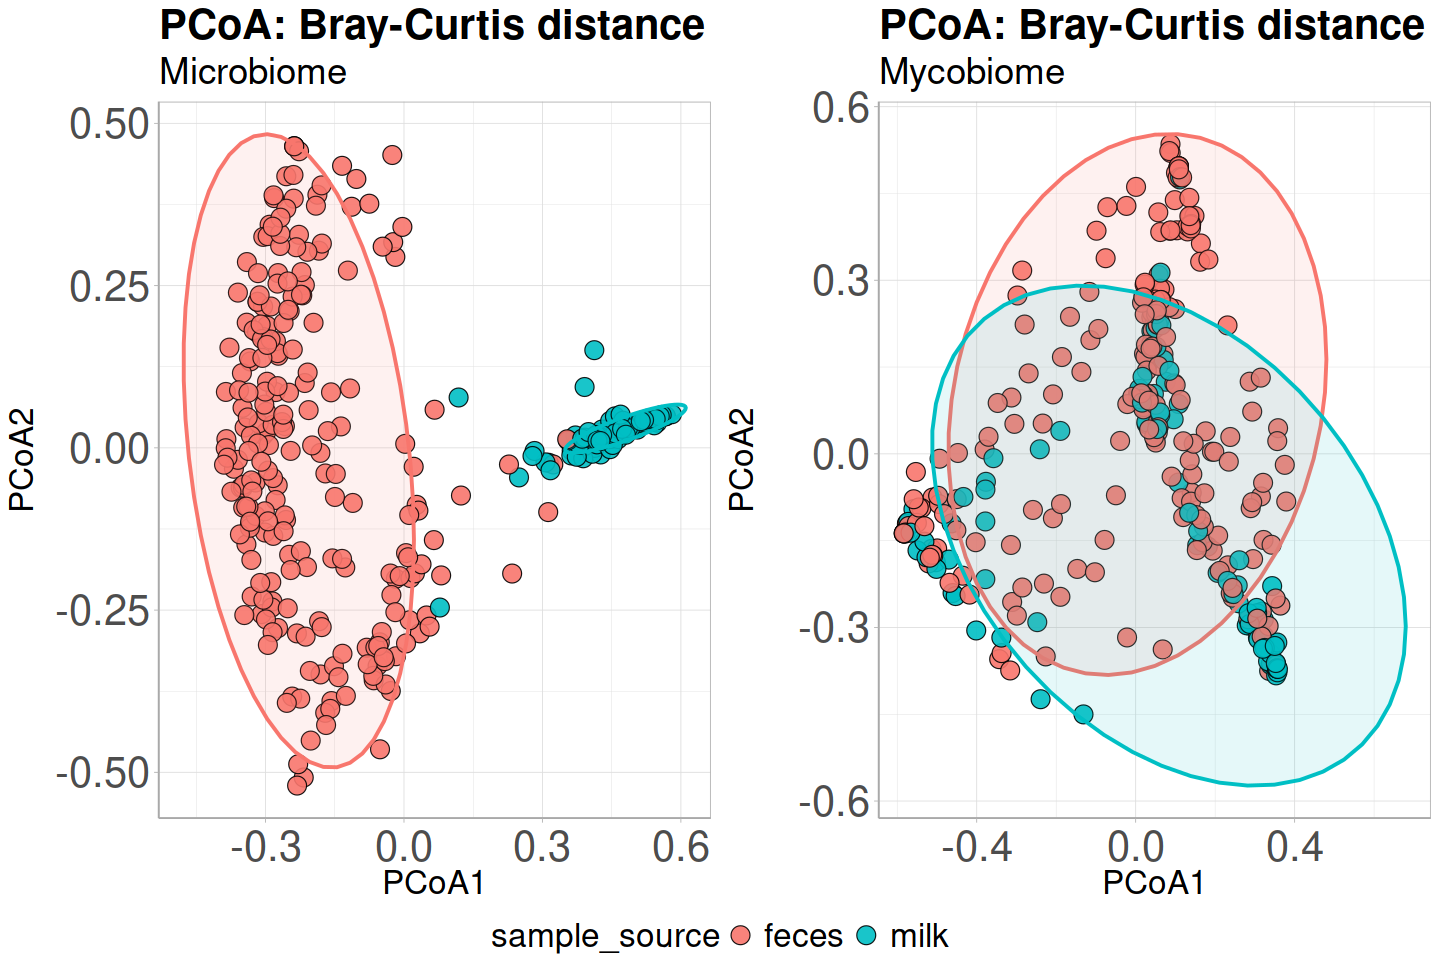

In [118]:
# compbine 2 figures together
width = 12
height = 8
options(repr.plot.width=width, repr.plot.height=height)
p <- ggarrange(pcoa_braycurtis_microbiome, pcoa_braycurtis_mycobiome,
          ncol = 2, nrow = 1, align = "hv", 
          common.legend = TRUE, legend = "bottom") 
print(p)

## PCoA Add-ons

### Loadings

In [24]:
# Compute covariation microbial genera with PCoA axis
# (The code is adjusted from biplot function of ape library)
# Credit source: https://github.com/cran/ape/blob/master/R/biplot.pcoa.R

compute_loadings <- function(x, Y) {
    plot.axes=c(1,2)
    pr.coo <- x$vectors
    n <- nrow(Y)
    points.stand <- scale(pr.coo[,plot.axes])
    S <- cov(Y, points.stand)
    U <- S %*% diag((x$values$Eigenvalues[plot.axes]/(n-1))^(-0.5))
    colnames(U) <- c('PCoA1', 'PCoA2')
    U <- data.frame(U)
    U['Length'] <- sqrt(U[['PCoA1']]**2+U[['PCoA2']]**2)
    U <- U[order(-U[['Length']]), ]
    U['direction'] <- (U['PCoA1']/abs(U['PCoA1'])+1)/2+(U['PCoA2']/abs(U['PCoA2'])+3)
    return(U)
}

In [25]:
# compute biplot (project microbial genera on new axis)
loadings_microbiome <- compute_loadings(pcoa_res_microbiome, otu_table(ps_microbiome))
# choose top 5 loadings_microbiome with largest covariance for first 2 PC axis
loadings_microbiome_selected <- loadings_microbiome[1:5, ]
loadings_microbiome_selected['names'] <- rownames(loadings_microbiome_selected)
# select 1 laoding per each plot quadrant
loadings_microbiome_selected <- loadings_microbiome_selected[row.names(unique(loadings_microbiome_selected['direction'])), ]

In [28]:
# compute biplot (project microbial genera on new axis)
loadings_mycobiome <- compute_loadings(pcoa_res_mycobiome, otu_table(ps_mycobiome))
# choose top 5 loadings_mycobiome with largest covariance for first 2 PC axis
loadings_mycobiome_selected <- loadings_mycobiome[1:5, ]
loadings_mycobiome_selected['names'] <- rownames(loadings_mycobiome_selected)
# select 1 laoding per each plot quadrant
loadings_mycobiome_selected <- loadings_mycobiome_selected[row.names(unique(loadings_mycobiome_selected['direction'])), ]

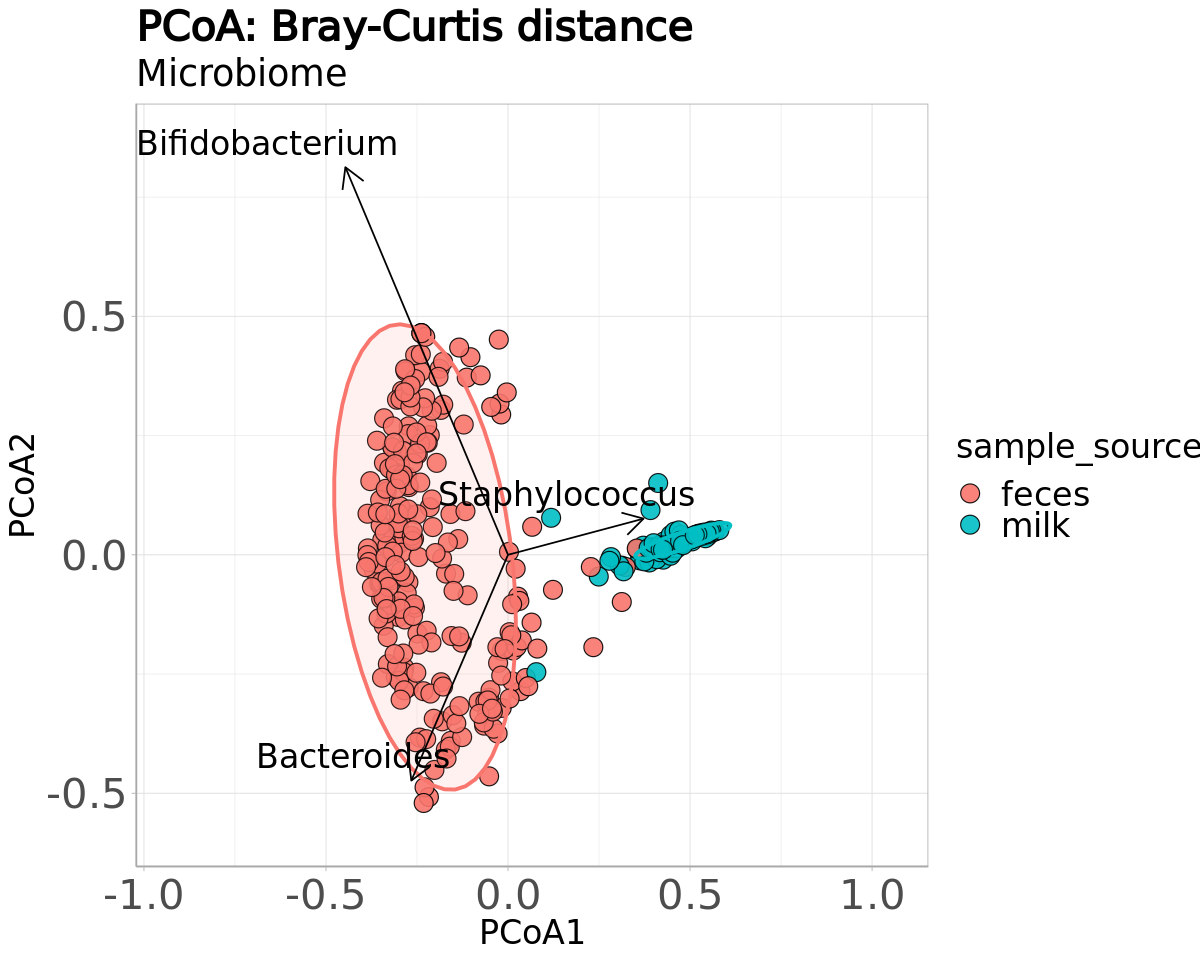

In [26]:
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_microbiome <- ggplot(data = pcoa_coordinates_microbiome, aes(x=PCoA1, y=PCoA2)) +
# plot sample values projected on PCoA
      geom_point(aes(fill = sample_source), 
                 size = 5, alpha=0.9, pch=21) +
# plot group circles
      stat_ellipse(geom = "polygon",
                   aes(color = sample_source, 
                       fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
################################### ADD-ON #####################################
# plot projected microbial genera
      geom_segment(data = loadings_microbiome_selected, 
                   aes(x = 0, y = 0, xend = PCoA1, yend = PCoA2), 
                   arrow = arrow(length = unit(0.03, "npc")), alpha = 1) + 
# plot names of the projected genera
      geom_text(data = loadings_microbiome_selected, 
                mapping = aes(x = PCoA1, y = PCoA2, label = names), 
                hjust = 0.8, vjust = -0.5, colour = "black", size = 7) +
# expand x and y limits to make plot better looking
      scale_x_continuous(expand = expansion(mult = 0.5)) +
      scale_y_continuous(expand = expansion(mult = 0.1)) +
################################################################################
# add titles
      labs(
           title = "PCoA: Bray-Curtis distance", 
           subtitle = "Microbiome") +
# custom plot design
      theme_light() +
      theme(axis.text=element_text(size=25),
            axis.title=element_text(size=20), 
            plot.title=element_text(size=25, face="bold"),
            plot.subtitle=element_text(size=22, face="plain"),
            plot.caption = element_text(face = "italic"),
            axis.text.x.bottom = element_text(size=25, angle=0, face='plain', hjust=0.5, vjust=0.5),
            text = element_text(size = 25), 
            legend.title=element_text(size=20),
            axis.line = element_line(color = "darkgrey"))  
pcoa_braycurtis_microbiome

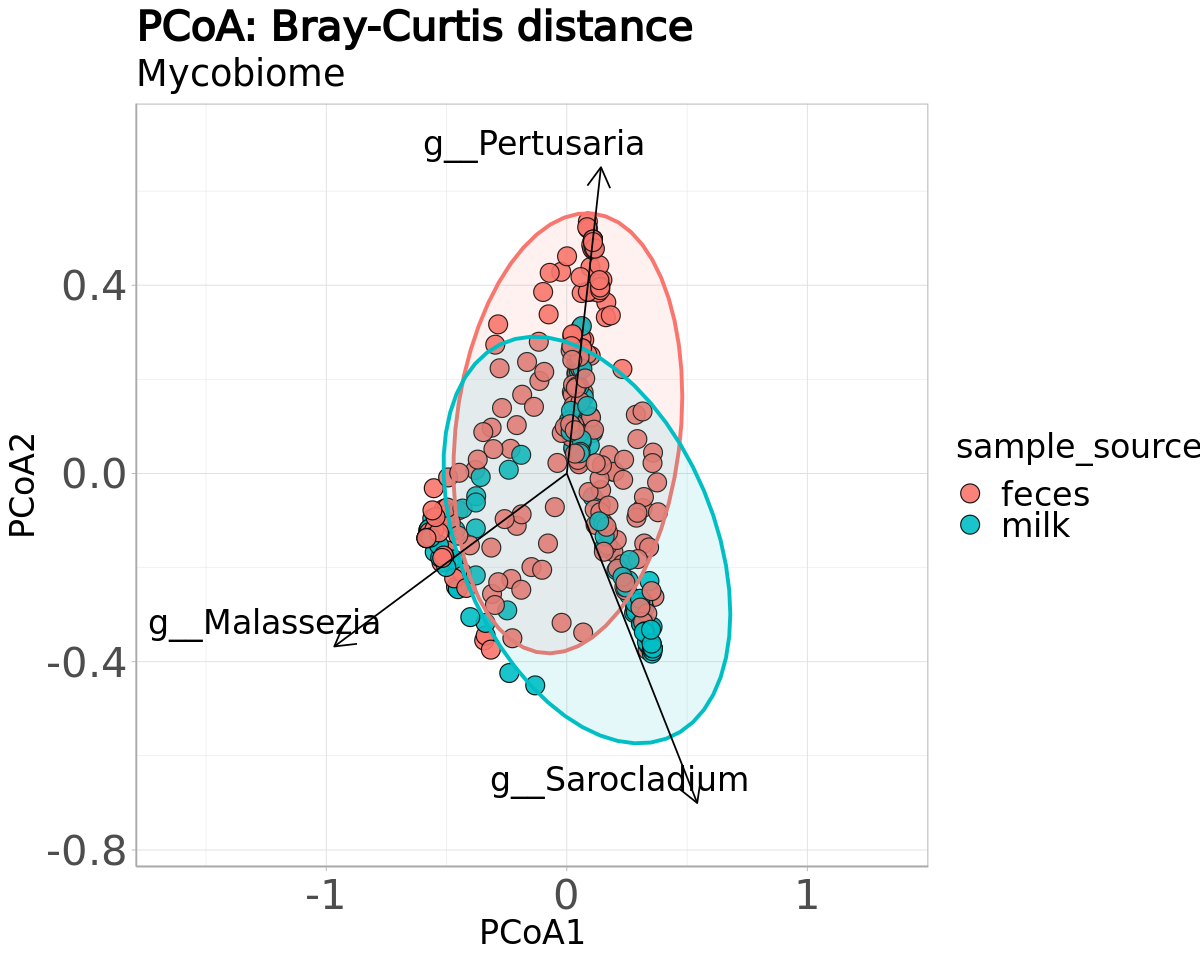

In [29]:
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_mycobiome <- ggplot(data = pcoa_coordinates_mycobiome, aes(x=PCoA1, y=PCoA2)) +
# plot sample values projected on PCoA
      geom_point(aes(fill = sample_source), 
                 size = 5, alpha=0.9, pch=21) +
# plot group circles
      stat_ellipse(geom = "polygon",
                   aes(color = sample_source, 
                       fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
################################### ADD-ON #####################################
# plot projected microbial genera
      geom_segment(data = loadings_mycobiome_selected, 
                   aes(x = 0, y = 0, xend = PCoA1, yend = PCoA2), 
                   arrow = arrow(length = unit(0.03, "npc")), alpha = 1) + 
# plot names of the projected genera
      geom_text(data = loadings_mycobiome_selected, 
                mapping = aes(x = PCoA1, y = PCoA2, label = names), 
                hjust = 0.8, vjust = -0.5, colour = "black", size = 7) +
# expand x and y limits to make plot better looking
      scale_x_continuous(expand = expansion(mult = 0.5)) +
      scale_y_continuous(expand = expansion(mult = 0.1)) +
################################################################################
# add titles
      labs(
           title = "PCoA: Bray-Curtis distance", 
           subtitle = "Mycobiome") +
# custom plot design
      theme_light() +
      theme(axis.text=element_text(size=25),
            axis.title=element_text(size=20), 
            plot.title=element_text(size=25, face="bold"),
            plot.subtitle=element_text(size=22, face="plain"),
            plot.caption = element_text(face = "italic"),
            axis.text.x.bottom = element_text(size=25, angle=0, face='plain', hjust=0.5, vjust=0.5),
            text = element_text(size = 25), 
            legend.title=element_text(size=20),
            axis.line = element_line(color = "darkgrey"))  
pcoa_braycurtis_mycobiome

### Permanova

In [30]:
# permanova test
set.seed(234) # set see for reproducibility
permanova_microbiome <- adonis2(as.formula(paste0("bray_curtis_dist_microbiome ~  ", 'sample_source')), 
                    data=data.frame(sample_data(ps_microbiome)), permutations=9999)
permanova_microbiome

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample_source,1,31.78479,0.2984978,141.6956,1e-04
Residual,333,74.69769,0.7015022,NA,NA
Total,334,106.48248,1.0000000,NA,NA


In [31]:
# permanova test
set.seed(234) # set see for reproducibility
permanova_mycobiome <- adonis2(as.formula(paste0("bray_curtis_dist_mycobiome ~  ", 'sample_source')), 
                    data=data.frame(sample_data(ps_mycobiome)), permutations=9999)
permanova_mycobiome

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample_source,1,3.767247,0.02902908,9.955688,1e-04
Residual,333,126.007676,0.97097092,NA,NA
Total,334,129.774922,1.00000000,NA,NA


### Explained variance

In [32]:
# calculate explained variance
explained_variance_microbiome <- pcoa_res_microbiome$values$Relative_eig * 100
explained_variance_mycobiome <- pcoa_res_mycobiome$values$Relative_eig * 100

### Updated plots

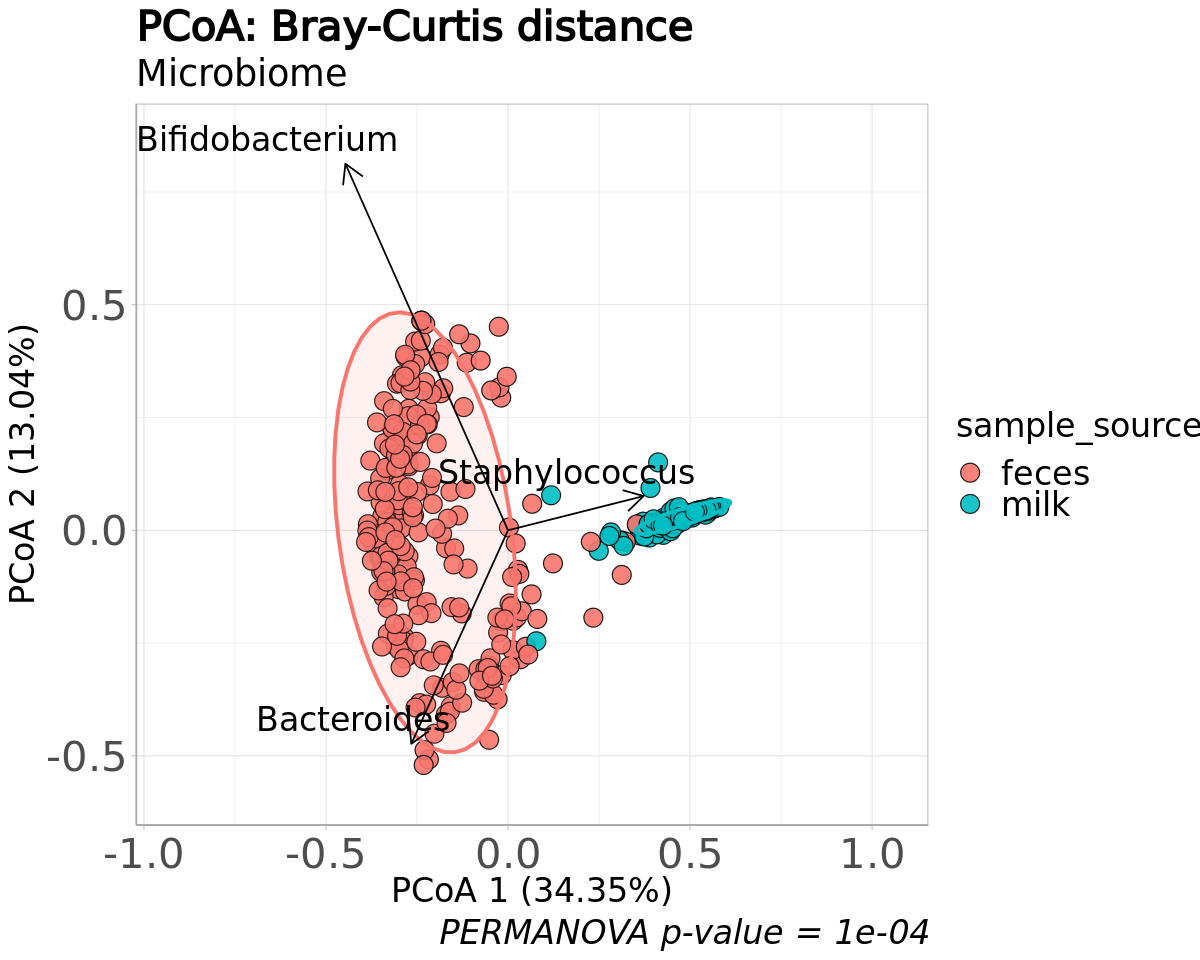

In [33]:
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_microbiome <- ggplot(data = pcoa_coordinates_microbiome, aes(x=PCoA1, y=PCoA2)) +
# plot sample values projected on PCoA
      geom_point(aes(fill = sample_source), 
                 size = 5, alpha=0.9, pch=21) +
# plot group circles
      stat_ellipse(geom = "polygon",
                   aes(color = sample_source, 
                       fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
# plot projected microbial genera
      geom_segment(data = loadings_microbiome_selected, 
                   aes(x = 0, y = 0, xend = PCoA1, yend = PCoA2), 
                   arrow = arrow(length = unit(0.03, "npc")), alpha = 1) + 
# plot names of the projected genera
      geom_text(data = loadings_microbiome_selected, 
                mapping = aes(x = PCoA1, y = PCoA2, label = names), 
                hjust = 0.8, vjust = -0.5, colour = "black", size = 7) +
# expand x and y limits to make plot better looking
      scale_x_continuous(expand = expansion(mult = 0.5)) +
      scale_y_continuous(expand = expansion(mult = 0.1)) +
################################### ADD-ON #####################################
# add titles
      labs(x = paste0("PCoA 1 (", sprintf('%.2f', explained_variance_microbiome[1]), "%)"), 
           y = paste0("PCoA 2 (", sprintf('%.2f', explained_variance_microbiome[2]), "%)"), 
           title = "PCoA: Bray-Curtis distance", 
           subtitle = "Microbiome",
           caption = paste0("PERMANOVA p-value = ", permanova_microbiome['sample_source', 'Pr(>F)']))+
################################################################################
# custom plot design
      theme_light() +
      theme(axis.text=element_text(size=25),
            axis.title=element_text(size=20), 
            plot.title=element_text(size=25, face="bold"),
            plot.subtitle=element_text(size=22, face="plain"),
            plot.caption = element_text(face = "italic"),
            axis.text.x.bottom = element_text(size=25, angle=0, face='plain', hjust=0.5, vjust=0.5),
            text = element_text(size = 25), 
            legend.title=element_text(size=20),
            axis.line = element_line(color = "darkgrey"))  
pcoa_braycurtis_microbiome

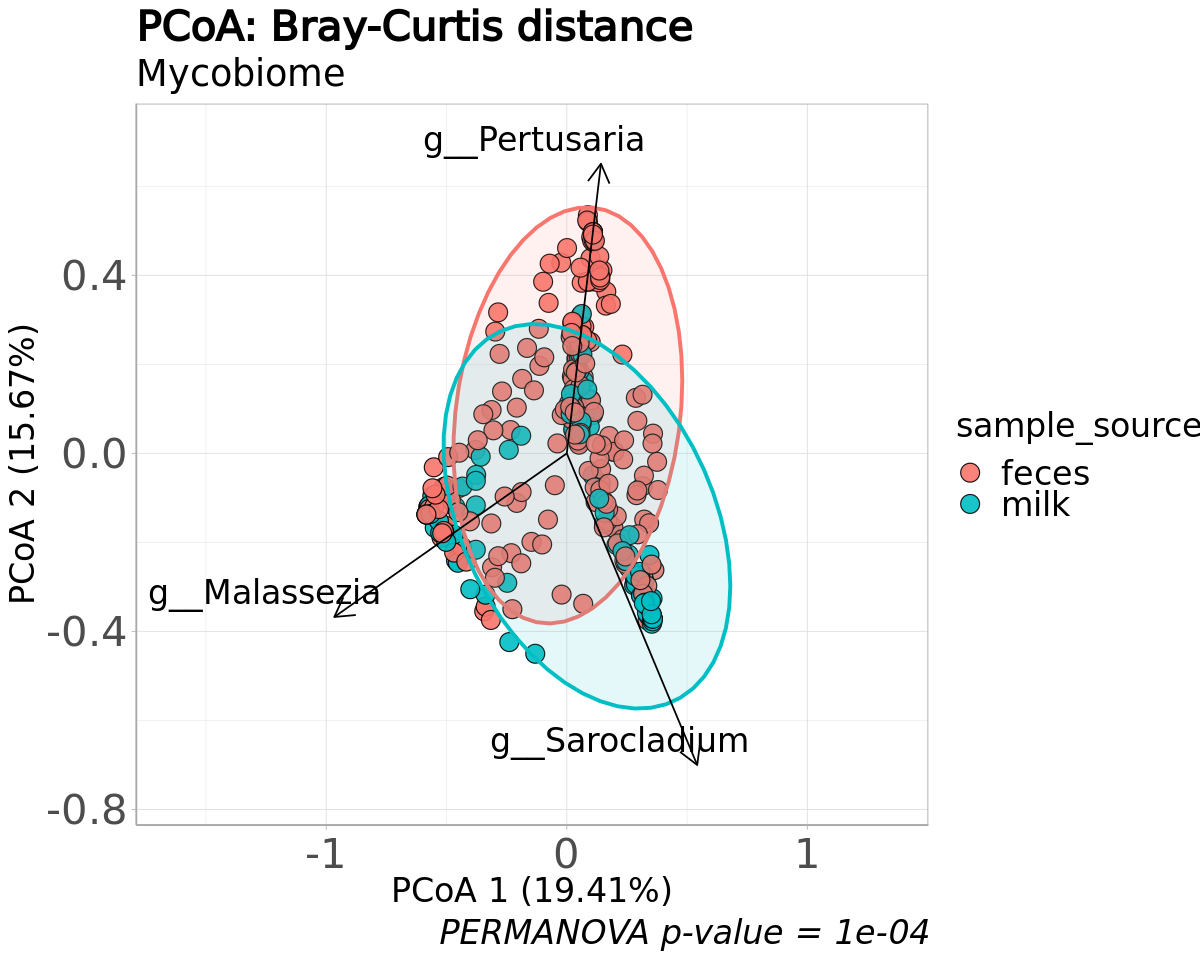

In [34]:
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_braycurtis_mycobiome <- ggplot(data = pcoa_coordinates_mycobiome, aes(x=PCoA1, y=PCoA2)) +
# plot sample values projected on PCoA
      geom_point(aes(fill = sample_source), 
                 size = 5, alpha=0.9, pch=21) +
# plot group circles
      stat_ellipse(geom = "polygon",
                   aes(color = sample_source, 
                       fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
# plot projected microbial genera
      geom_segment(data = loadings_mycobiome_selected, 
                   aes(x = 0, y = 0, xend = PCoA1, yend = PCoA2), 
                   arrow = arrow(length = unit(0.03, "npc")), alpha = 1) + 
# plot names of the projected genera
      geom_text(data = loadings_mycobiome_selected, 
                mapping = aes(x = PCoA1, y = PCoA2, label = names), 
                hjust = 0.8, vjust = -0.5, colour = "black", size = 7) +
# expand x and y limits to make plot better looking
      scale_x_continuous(expand = expansion(mult = 0.5)) +
      scale_y_continuous(expand = expansion(mult = 0.1)) +
################################### ADD-ON #####################################
# add titles
      labs(x = paste0("PCoA 1 (", sprintf('%.2f', explained_variance_mycobiome[1]), "%)"), 
           y = paste0("PCoA 2 (", sprintf('%.2f', explained_variance_mycobiome[2]), "%)"), 
           title = "PCoA: Bray-Curtis distance", 
           subtitle = "Mycobiome",
           caption = paste0("PERMANOVA p-value = ", permanova_mycobiome['sample_source', 'Pr(>F)']))+
################################################################################
# custom plot design
      theme_light() +
      theme(axis.text=element_text(size=25),
            axis.title=element_text(size=20), 
            plot.title=element_text(size=25, face="bold"),
            plot.subtitle=element_text(size=22, face="plain"),
            plot.caption = element_text(face = "italic"),
            axis.text.x.bottom = element_text(size=25, angle=0, face='plain', hjust=0.5, vjust=0.5),
            text = element_text(size = 25), 
            legend.title=element_text(size=20),
            axis.line = element_line(color = "darkgrey"))  
pcoa_braycurtis_mycobiome

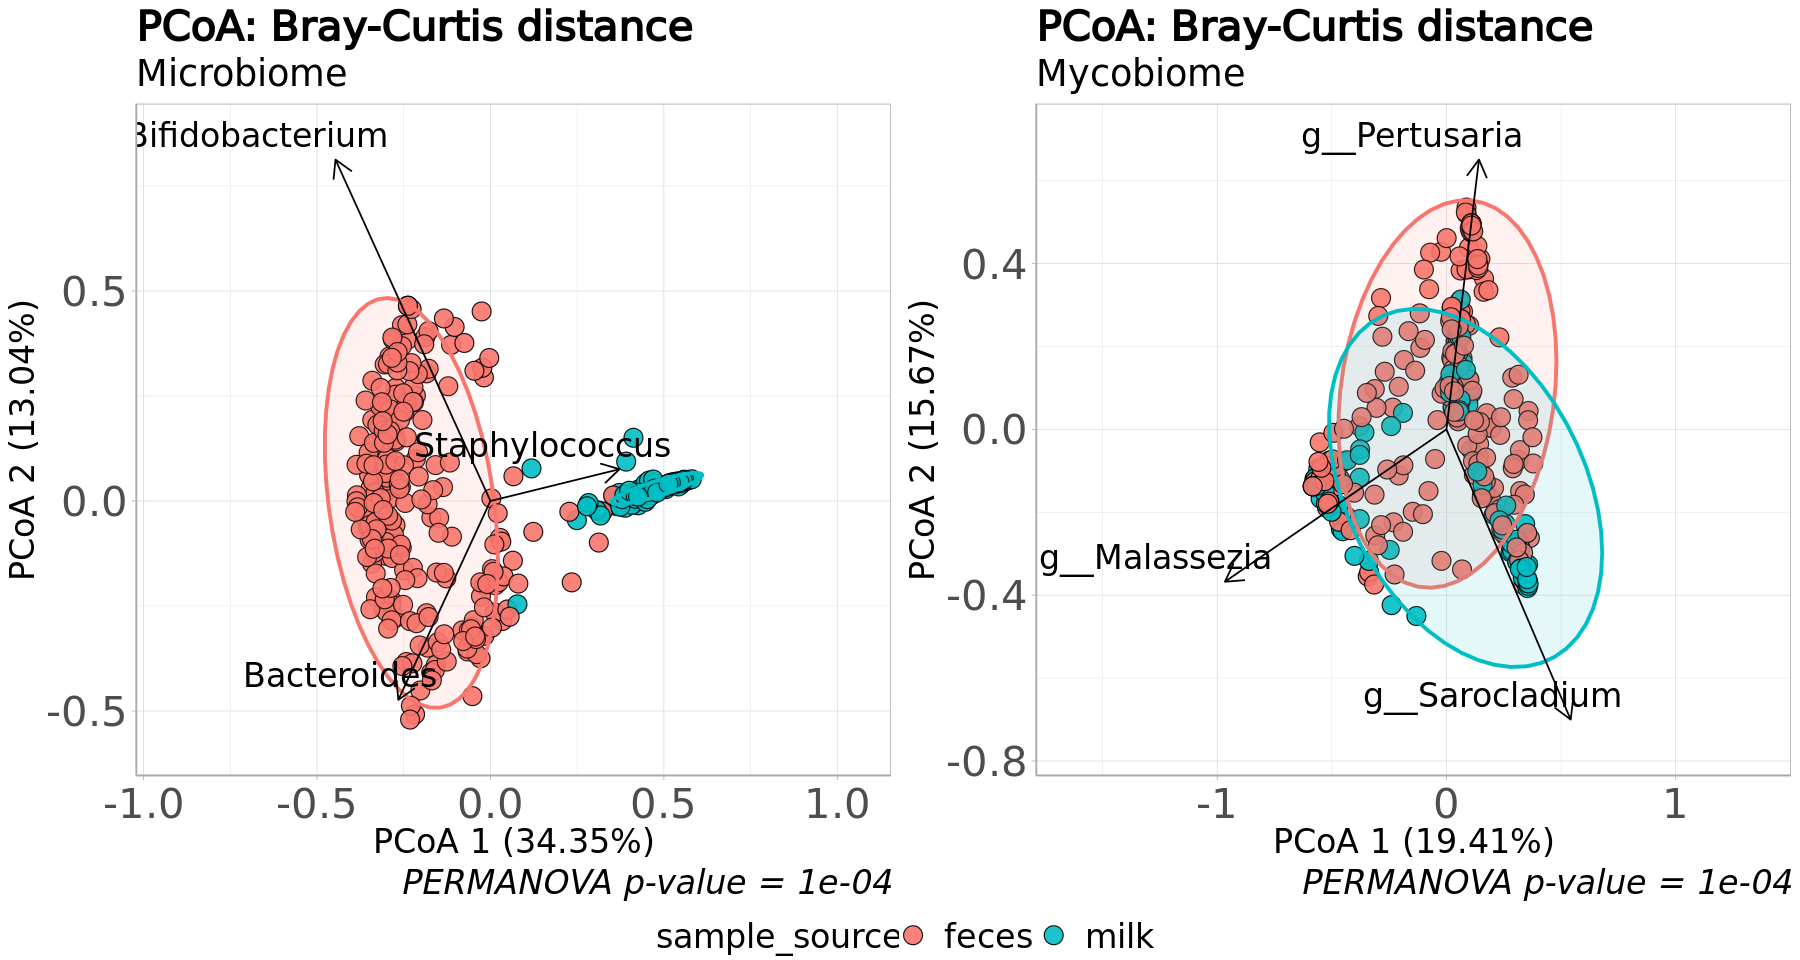

In [35]:
# compbine 2 figures together
width = 15
height = 8
options(repr.plot.width=width, repr.plot.height=height)
p <- ggarrange(pcoa_braycurtis_microbiome, pcoa_braycurtis_mycobiome,
          ncol = 2, nrow = 1, align = "hv", 
          common.legend = TRUE, legend = "bottom") 
print(p)

# PCoA based on Unifrac distances

In [ ]:
ps_microbiome <- readRDS('../../data/data_analysis/ps_microbiome.with_tree.rds')
ps_mycobiome <- readRDS('../../data/data_analysis/ps_mycobiome.with_tree.rds')
ps_microbiome
ps_mycobiome

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 14691 taxa and 384 samples ]
sample_data() Sample Data:       [ 384 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 14691 taxa by 7 taxonomic ranks ]
phy_tree()    Phylogenetic Tree: [ 14691 tips and 14689 internal nodes ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 6159 taxa and 404 samples ]
sample_data() Sample Data:       [ 404 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 6159 taxa by 7 taxonomic ranks ]
phy_tree()    Phylogenetic Tree: [ 6159 tips and 6159 internal nodes ]

In [75]:
phy_tree(ps_microbiome) <- midpoint.root(phy_tree(ps_mycobiome))

In [76]:
ps_microbiome <- prune_samples(rowSums(otu_table(ps_microbiome)) > 0, ps_microbiome)
ps_mycobiome <- prune_samples(rowSums(otu_table(ps_mycobiome)) > 0, ps_mycobiome)
ps_microbiome <- transform_sample_counts(ps_microbiome, function(x) {x / sum(x)})
ps_mycobiome <- transform_sample_counts(ps_mycobiome, function(x) {x / sum(x)})

metadata_microbiome <- data.frame(sample_data(ps_microbiome))
metadata_microbiome <- metadata_microbiome[, c('host.age', 'host.body.product', 
                                     'host.diet', 'host.sex', 
                                     'host.subject.id')]
metadata_microbiome <- clean_metadata(metadata_microbiome)
sample_data(ps_microbiome) <- metadata_microbiome
sample_names(ps_microbiome) <- metadata_microbiome[['sample_id']]


metadata_mycobiome <- data.frame(sample_data(ps_mycobiome))
metadata_mycobiome <- metadata_mycobiome[, c('host.age', 'host.body.product', 
                                     'host.diet', 'host.sex', 
                                     'host.subject.id')]
metadata_mycobiome <- clean_metadata(metadata_mycobiome)
sample_data(ps_mycobiome) <- metadata_mycobiome
sample_names(ps_mycobiome) <- metadata_mycobiome[['sample_id']]

In [77]:
sample_ids_microbiome <- metadata_microbiome[['sample_id']]
sample_ids_mycobiome <- metadata_mycobiome[['sample_id']]
sample_ids <- intersect(sample_ids_microbiome, sample_ids_mycobiome)

ps_microbiome <- prune_samples(sample_ids, ps_microbiome)
ps_mycobiome <- prune_samples(sample_ids, ps_mycobiome)
# ensure samples order
otu_table(ps_microbiome) <- otu_table(ps_microbiome)[sample_ids, ]
otu_table(ps_mycobiome) <- otu_table(ps_mycobiome)[sample_ids, ]
ps_microbiome
ps_mycobiome

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 6159 taxa and 343 samples ]
sample_data() Sample Data:       [ 343 samples by 6 sample variables ]
tax_table()   Taxonomy Table:    [ 6159 taxa by 7 taxonomic ranks ]
phy_tree()    Phylogenetic Tree: [ 6159 tips and 6158 internal nodes ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 6159 taxa and 343 samples ]
sample_data() Sample Data:       [ 343 samples by 6 sample variables ]
tax_table()   Taxonomy Table:    [ 6159 taxa by 7 taxonomic ranks ]
phy_tree()    Phylogenetic Tree: [ 6159 tips and 6159 internal nodes ]

In [78]:
# Calculate UniFrac with alpha values for unweighted (0), weighted (1), and a compromise (0.5)
unifrac_microbiome <- GUniFrac(otu_table(ps_microbiome), 
                               phy_tree(ps_microbiome), alpha = c(0, 0.5, 1), verbose=TRUE)$unifracs

Accumulate the abundance along the tree branches...
Compute pairwise distances ...
Completed!


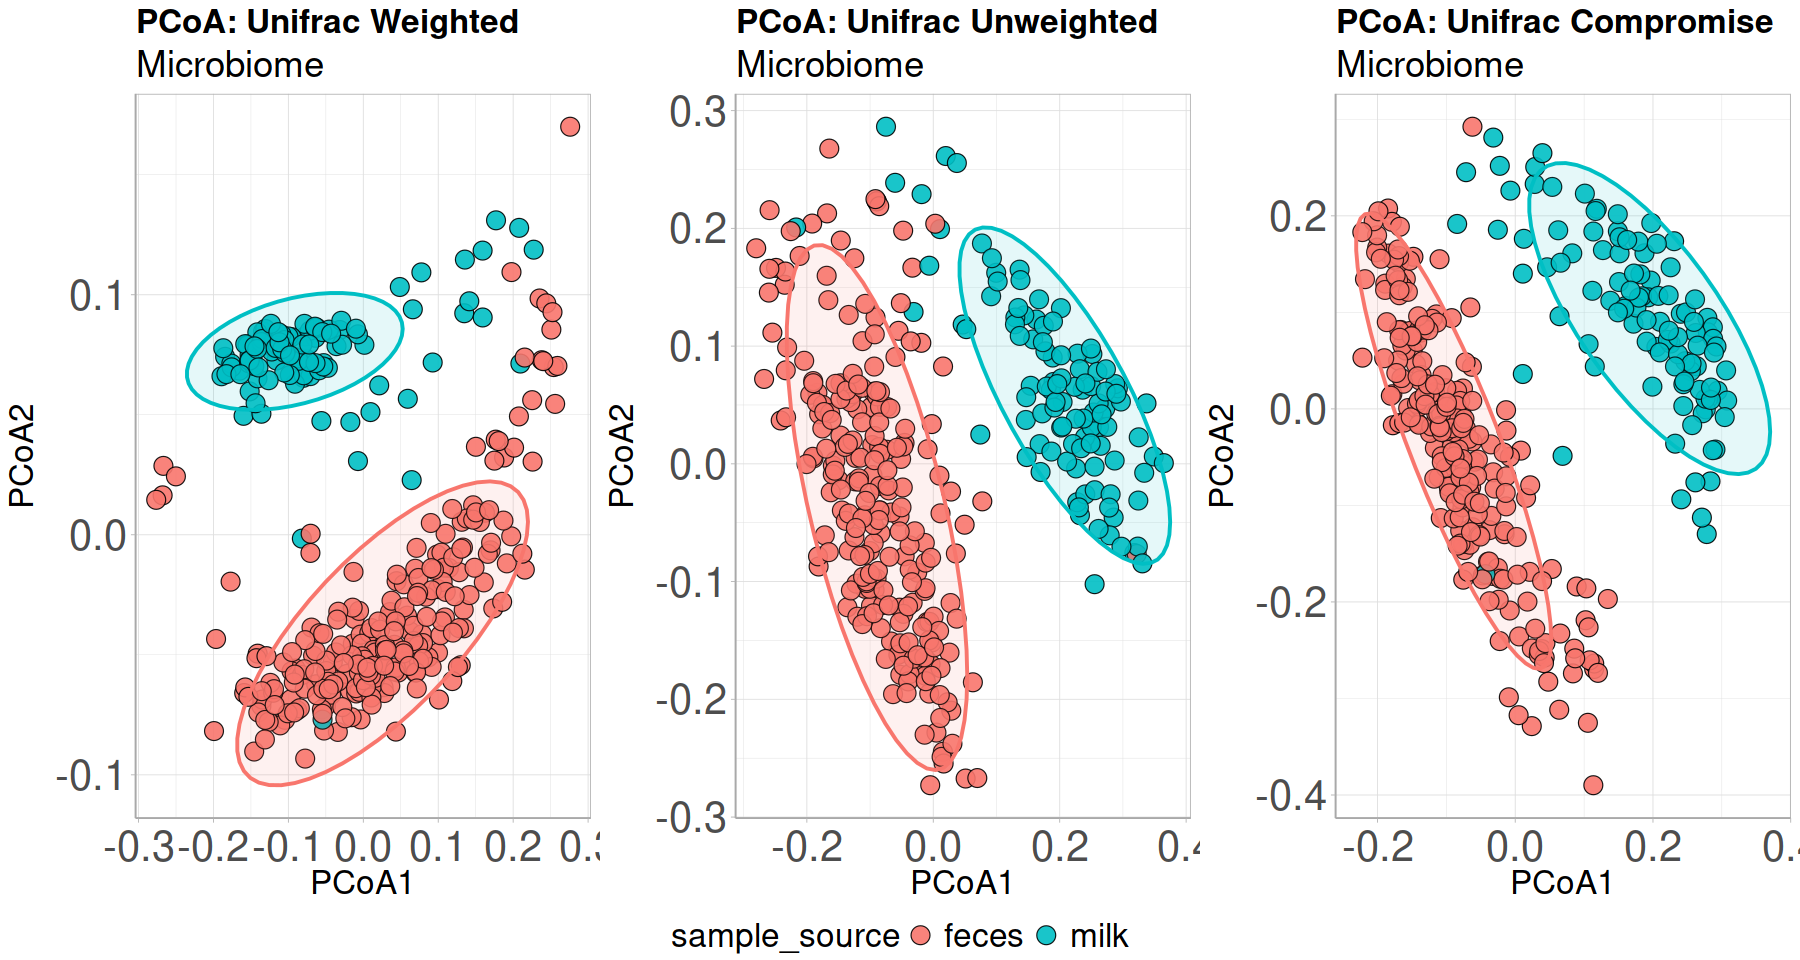

In [79]:
unifrac_types <- list(Weighted='d_1', Unweighted='d_UW', Compromise='d_0.5')
pcoa_plots <- lapply(names(unifrac_types), function(unifrac_type) {
    dist <- unifrac_microbiome[, , unifrac_types[[unifrac_type]]]
    # compute pcoa
    pcoa_res_microbiome <- pcoa(dist)

    # reformat the result table for plotting with ggplot
    pcoa_coordinates_microbiome <- data.frame(pcoa_res_microbiome$vectors)[, c('Axis.1', 'Axis.2')]
    colnames(pcoa_coordinates_microbiome) <- c('PCoA1', 'PCoA2')
    pcoa_coordinates_microbiome <- cbind(pcoa_coordinates_microbiome, sample_data(ps_microbiome))
    pcoa_coordinates_microbiome$sample_type <- 'Microbiome' 
    
    
    p <- ggplot(data = pcoa_coordinates_microbiome, aes(x=PCoA1, y=PCoA2)) +
    # plot sample values projected on PCoA
          geom_point(aes(fill = sample_source), 
                     size = 5, alpha=0.9, pch=21) +
    # plot group circles
          stat_ellipse(geom = "polygon",
                       aes(color = sample_source, 
                           fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
    # add titles
          labs(
               title = paste0("PCoA: Unifrac ", unifrac_type), 
               subtitle = "Microbiome") +
    # custom plot design
          theme_light() +
          theme(axis.text=element_text(size=25),
                axis.title=element_text(size=20), 
                plot.title=element_text(size=20, face="bold"),
                plot.subtitle=element_text(size=22, face="plain"),
                plot.caption = element_text(face = "italic"),
                axis.text.x.bottom = element_text(size=25, angle=0, face='plain', hjust=0.5, vjust=0.5),
                text = element_text(size = 25), 
                legend.title=element_text(size=20),
                axis.line = element_line(color = "darkgrey"))  
    return(p)
})

# combine figures together
width = 15
height = 8
options(repr.plot.width=width, repr.plot.height=height)
p_combined <- ggarrange(pcoa_plots[[1]], pcoa_plots[[2]], pcoa_plots[[3]],
          ncol = 3, nrow = 1, align = "hv", 
          common.legend = TRUE, legend = "bottom") 
print(p_combined)

In [80]:
# Calculate UniFrac with alpha values for unweighted (0), weighted (1), and a compromise (0.5)
unifrac_mycobiome <- GUniFrac(otu_table(ps_mycobiome), 
                               phy_tree(ps_mycobiome), alpha = c(0, 0.5, 1))$unifracs

Accumulate the abundance along the tree branches...
Compute pairwise distances ...
Completed!


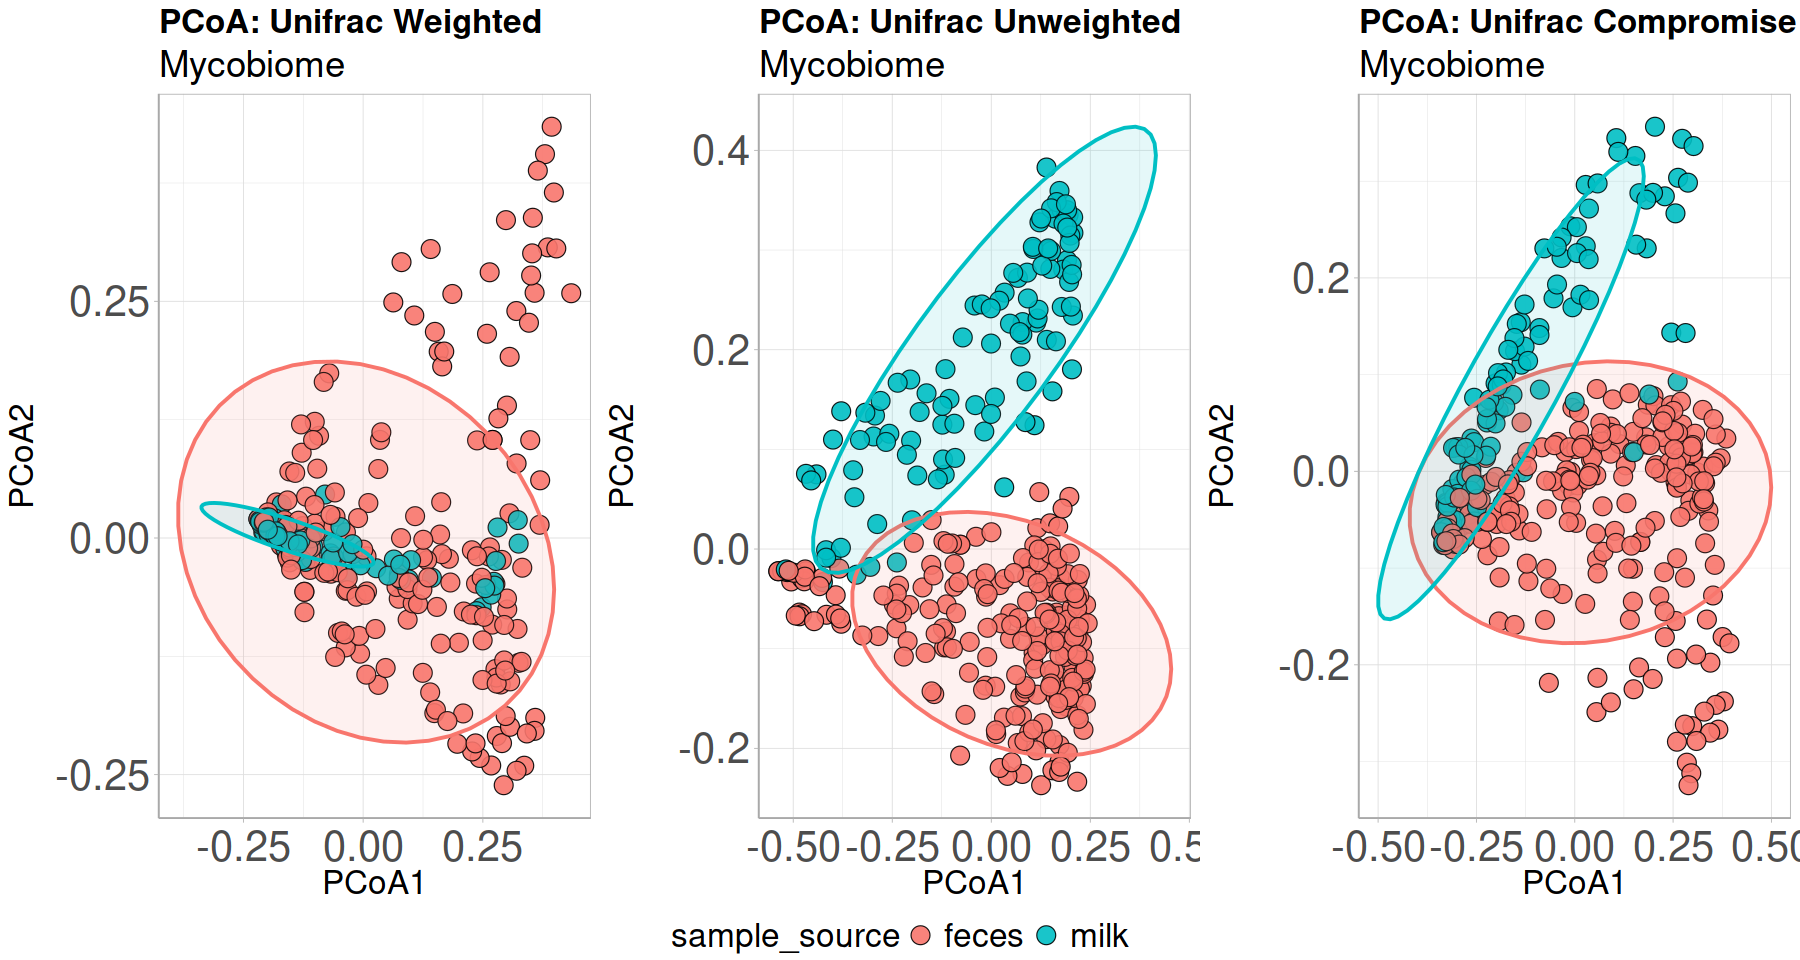

In [81]:
unifrac_types <- list(Weighted='d_1', Unweighted='d_UW', Compromise='d_0.5')
pcoa_plots <- lapply(names(unifrac_types), function(unifrac_type) {
    dist <- unifrac_mycobiome[, , unifrac_types[[unifrac_type]]]
    # compute pcoa
    pcoa_res_mycobiome <- pcoa(dist)

    # reformat the result table for plotting with ggplot
    pcoa_coordinates_mycobiome <- data.frame(pcoa_res_mycobiome$vectors)[, c('Axis.1', 'Axis.2')]
    colnames(pcoa_coordinates_mycobiome) <- c('PCoA1', 'PCoA2')
    pcoa_coordinates_mycobiome <- cbind(pcoa_coordinates_mycobiome, sample_data(ps_mycobiome))
    pcoa_coordinates_mycobiome$sample_type <- 'Mycobiome' 
    
    
    p <- ggplot(data = pcoa_coordinates_mycobiome, aes(x=PCoA1, y=PCoA2)) +
    # plot sample values projected on PCoA
          geom_point(aes(fill = sample_source), 
                     size = 5, alpha=0.9, pch=21) +
    # plot group circles
          stat_ellipse(geom = "polygon",
                       aes(color = sample_source, 
                           fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
    # add titles
          labs(
               title = paste0("PCoA: Unifrac ", unifrac_type), 
               subtitle = "Mycobiome") +
    # custom plot design
          theme_light() +
          theme(axis.text=element_text(size=25),
                axis.title=element_text(size=20), 
                plot.title=element_text(size=20, face="bold"),
                plot.subtitle=element_text(size=22, face="plain"),
                plot.caption = element_text(face = "italic"),
                axis.text.x.bottom = element_text(size=25, angle=0, face='plain', hjust=0.5, vjust=0.5),
                text = element_text(size = 25), 
                legend.title=element_text(size=20),
                axis.line = element_line(color = "darkgrey"))  
    return(p)
})

# combine figures together
width = 15
height = 8
options(repr.plot.width=width, repr.plot.height=height)
p_combined <- ggarrange(pcoa_plots[[1]], pcoa_plots[[2]], pcoa_plots[[3]],
          ncol = 3, nrow = 1, align = "hv", 
          common.legend = TRUE, legend = "bottom") 
print(p_combined)

# Procrustes analysis for PCoA Unweighted Unifrac
__"Procrustes analysis is named after a bandit from ancient Greek mythology that would hunt people down, and adjust their sizes to his iron bed by either cutting their limbs off or stretching them."__
<br>Citation source: https://medium.com/@olga_kravchenko/generalized-procrustes-analysis-with-python-numpy-c571e8e8a421
<br> Figure source: https://www.scielo.br/j/brag/a/w4DBp6nzxwvPFDR7JYWGWDr/?lang=en



<img src="https://minio.scielo.br/documentstore/1678-4499/w4DBp6nzxwvPFDR7JYWGWDr/fe4b2ee3c20d0671acaeb9176a3a4705df41e0d7.jpg">

In [82]:
dist <- unifrac_microbiome[, , unifrac_types[['Unweighted']]]
# compute pcoa
pcoa_res_microbiome <- pcoa(dist)

# reformat the result table for plotting with ggplot
pcoa_unifrac_coordinates_microbiome <- data.frame(pcoa_res_microbiome$vectors)[, c('Axis.1', 'Axis.2')]
colnames(pcoa_unifrac_coordinates_microbiome) <- c('PCoA1', 'PCoA2')
pcoa_unifrac_coordinates_microbiome <- cbind(pcoa_unifrac_coordinates_microbiome, sample_data(ps_microbiome))
pcoa_unifrac_coordinates_microbiome$sample_type <- 'Microbiome' 

In [83]:
dist <- unifrac_mycobiome[, , unifrac_types[['Unweighted']]]
# compute pcoa
pcoa_res_mycobiome <- pcoa(dist)

# reformat the result table for plotting with ggplot
pcoa_unhifrac_coordinates_mycobiome <- data.frame(pcoa_res_mycobiome$vectors)[, c('Axis.1', 'Axis.2')]
colnames(pcoa_unhifrac_coordinates_mycobiome) <- c('PCoA1', 'PCoA2')
pcoa_unhifrac_coordinates_mycobiome <- cbind(pcoa_unhifrac_coordinates_mycobiome, sample_data(ps_mycobiome))
pcoa_unhifrac_coordinates_mycobiome$sample_type <- 'Mycobiome' 

In [91]:
pcoa_coordinates <- rbind(pcoa_unifrac_coordinates_microbiome,
                          pcoa_unhifrac_coordinates_mycobiome)

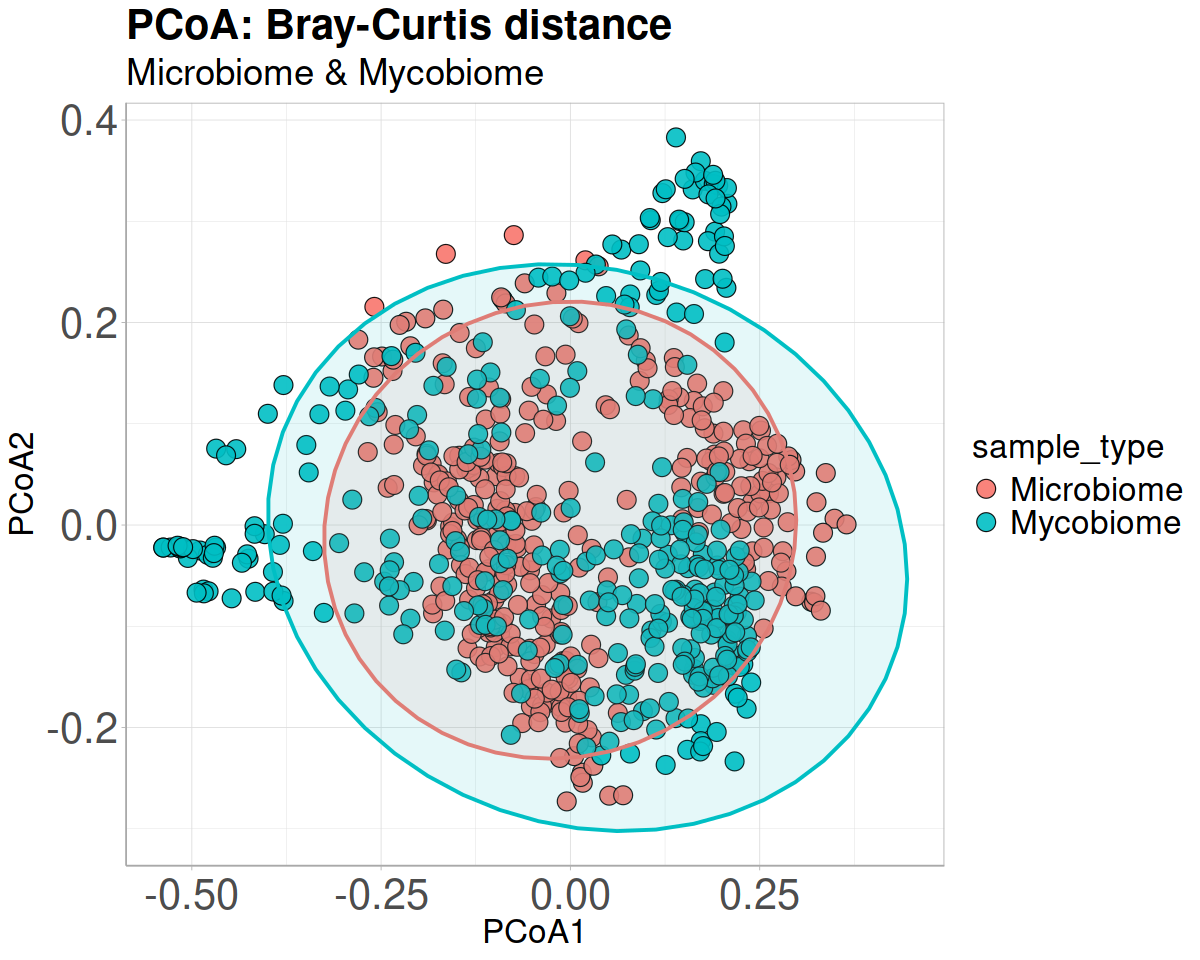

In [92]:
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates, aes(x=PCoA1, y=PCoA2)) +
# plot sample values projected on PCoA
      geom_point(aes(fill=sample_type), 
                 size = 5, alpha=0.9, pch=21) +
# plot group circles
      stat_ellipse(geom = "polygon",
                   aes(color = sample_type, 
                       fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
# add titles
      labs(
           title = "PCoA: Bray-Curtis distance", 
           subtitle = "Microbiome & Mycobiome") +
# custom plot design
      theme_light() +
      theme(axis.text=element_text(size=25),
            axis.title=element_text(size=20), 
            plot.title=element_text(size=25, face="bold"),
            plot.subtitle=element_text(size=22, face="plain"),
            plot.caption = element_text(face = "italic"),
            axis.text.x.bottom = element_text(size=25, angle=0, face='plain', hjust=0.5, vjust=0.5),
            text = element_text(size = 25), 
            legend.title=element_text(size=20),
            axis.line = element_line(color = "darkgrey"))  
pcoa_plot

In [94]:
n <- min(ncol(pcoa_res_microbiome$vectors), ncol(pcoa_res_mycobiome$vectors))
# n <- 2

procrustes_res <- procrustes(data.frame(pcoa_res_microbiome$vectors[, 1:n]), 
                             data.frame(pcoa_res_mycobiome$vectors[, 1:n]), 
                            scale=FALSE)
pcoa_rotated_mycobiome <- data.frame(procrustes_res$Yrot)
colnames(pcoa_rotated_mycobiome) <- paste0('PCoA', c(1:n))
pcoa_original_microbiome <- data.frame(procrustes_res$X)
colnames(pcoa_original_microbiome) <- paste0('PCoA', c(1:n))
pcoa_original_microbiome$sample_type <- 'Microbiome'
pcoa_rotated_mycobiome$sample_type <- 'Mycobiome'
pcoa_coordinates_procrustes <- rbind(pcoa_original_microbiome, pcoa_rotated_mycobiome)

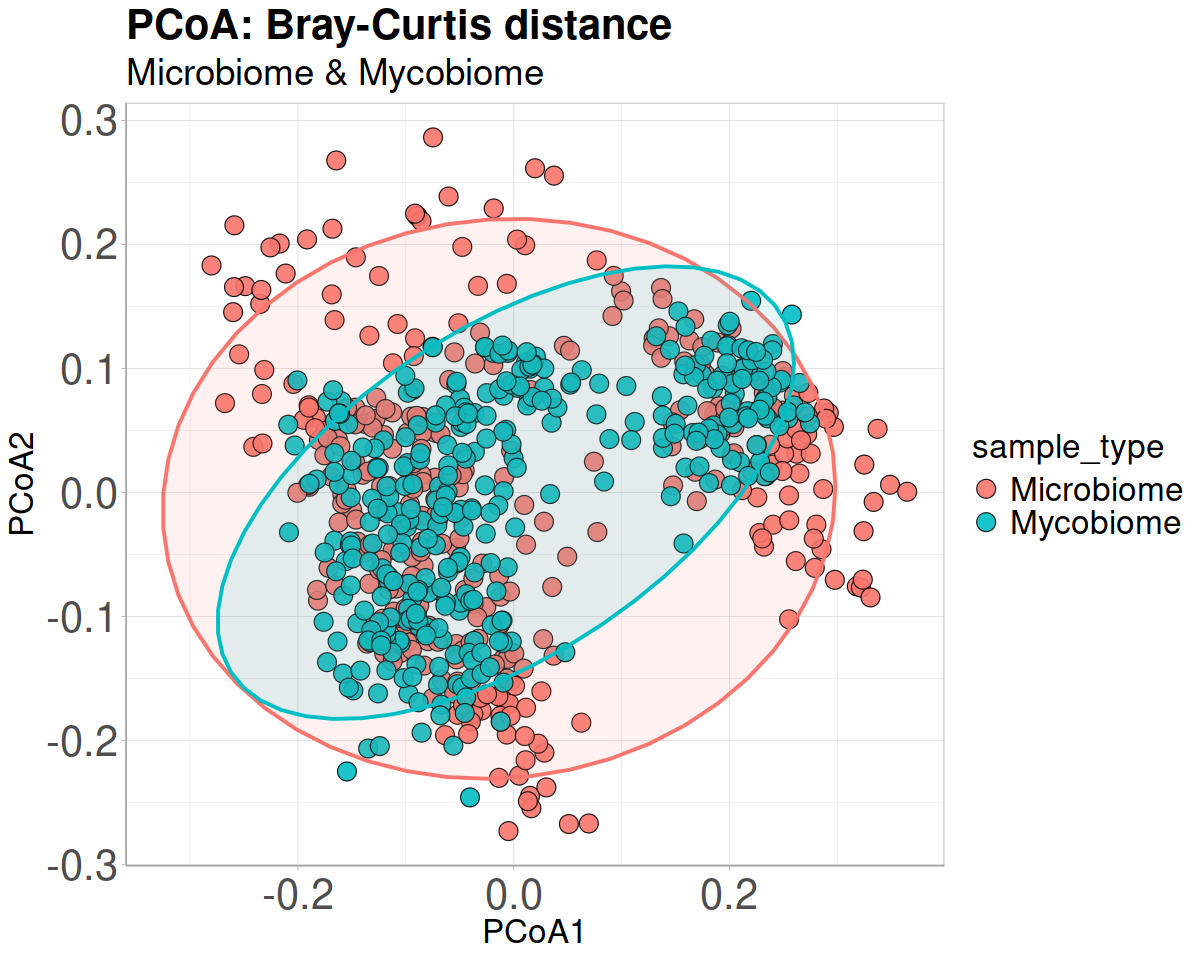

In [95]:
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates_procrustes, aes(x=PCoA1, y=PCoA2)) +
# plot sample values projected on PCoA
      geom_point(aes(fill=sample_type), 
                 size = 5, alpha=0.9, pch=21) +
# plot group circles
      stat_ellipse(geom = "polygon",
                   aes(color = sample_type, 
                       fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
# add titles
      labs(
           title = "PCoA: Bray-Curtis distance", 
           subtitle = "Microbiome & Mycobiome") +
# custom plot design
      theme_light() +
      theme(axis.text=element_text(size=25),
            axis.title=element_text(size=20), 
            plot.title=element_text(size=25, face="bold"),
            plot.subtitle=element_text(size=22, face="plain"),
            plot.caption = element_text(face = "italic"),
            axis.text.x.bottom = element_text(size=25, angle=0, face='plain', hjust=0.5, vjust=0.5),
            text = element_text(size = 25), 
            legend.title=element_text(size=20),
            axis.line = element_line(color = "darkgrey"))  
pcoa_plot

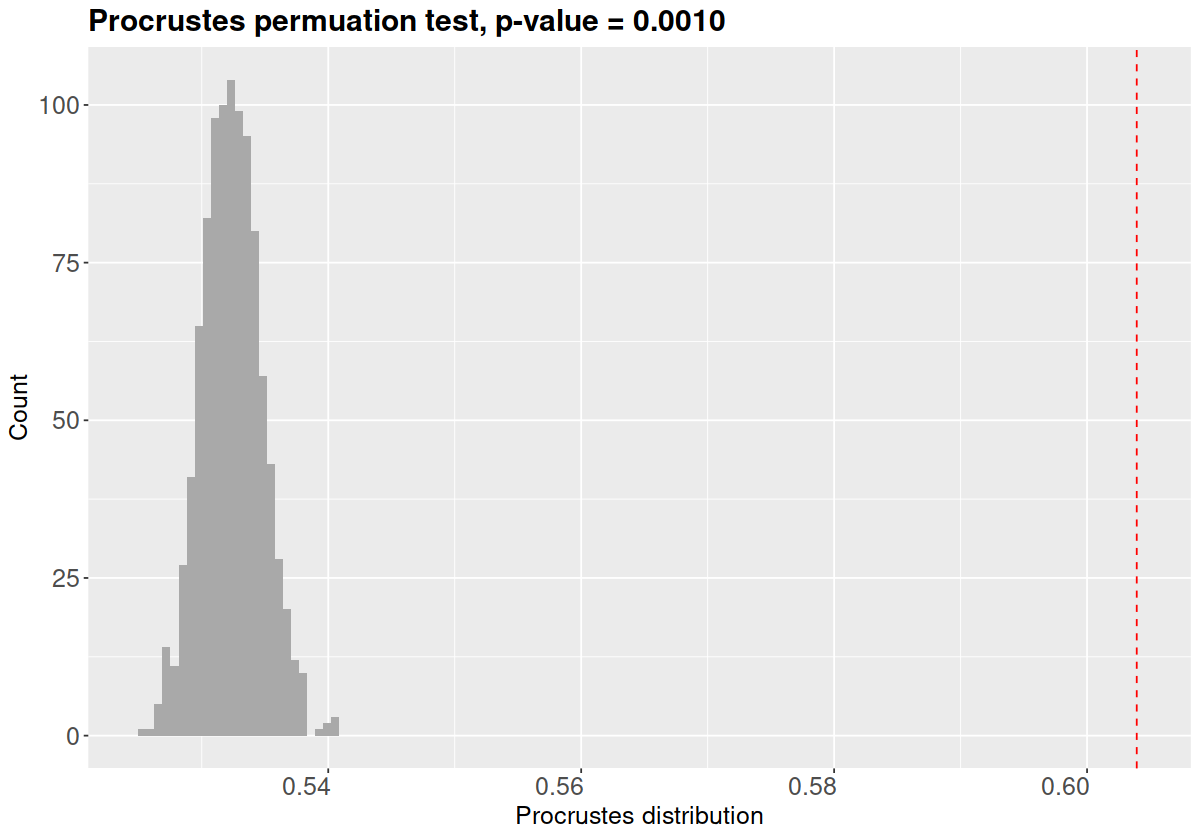

In [96]:
width = 10
height = 7
options(repr.plot.width=width, repr.plot.height=height)

n <- min(ncol(pcoa_res_microbiome$vectors), ncol(pcoa_res_mycobiome$vectors))
# n <- 2
set.seed(123)
procrustes_permutation <- protest(data.frame(pcoa_res_microbiome$vectors[, 1:n]), 
               data.frame(pcoa_res_mycobiome$vectors[, 1:n]), 
               scale=FALSE, permutations = 999)

procrustes_permutation_d <- data.frame(distances = procrustes_permutation$t)
procrustes_permutation_d0 <- procrustes_permutation$t0

procrustes_dist_plot <- ggplot(data = procrustes_permutation_d, aes(x = distances)) +
    geom_histogram(bins = 125, fill = "dark grey") +
    geom_vline(xintercept = procrustes_permutation_d0, lty = 2, color = "red") +
    labs(x = "Procrustes distribution", y = "Count") +
    theme(axis.text.x = element_text(hjust = 0.95, vjust=0.95),
          axis.text=element_text(size=15),
          axis.title=element_text(size=15),
          plot.title=element_text(size=18, face="bold")) + 
    theme(legend.position = "none") +
    ggtitle(paste0('Procrustes permuation test, p-value = ', 
                   sprintf('%.4f', procrustes_permutation$signif)))
procrustes_dist_plot

# Procrustes analysis for PCoA Bray-Curtis
__"Procrustes analysis is named after a bandit from ancient Greek mythology that would hunt people down, and adjust their sizes to his iron bed by either cutting their limbs off or stretching them."__
<br>Citation source: https://medium.com/@olga_kravchenko/generalized-procrustes-analysis-with-python-numpy-c571e8e8a421
<br> Figure source: https://www.scielo.br/j/brag/a/w4DBp6nzxwvPFDR7JYWGWDr/?lang=en

<img src="https://minio.scielo.br/documentstore/1678-4499/w4DBp6nzxwvPFDR7JYWGWDr/fe4b2ee3c20d0671acaeb9176a3a4705df41e0d7.jpg">

In [119]:
pcoa_coordinates <- rbind(pcoa_coordinates_microbiome,
                          pcoa_coordinates_mycobiome)

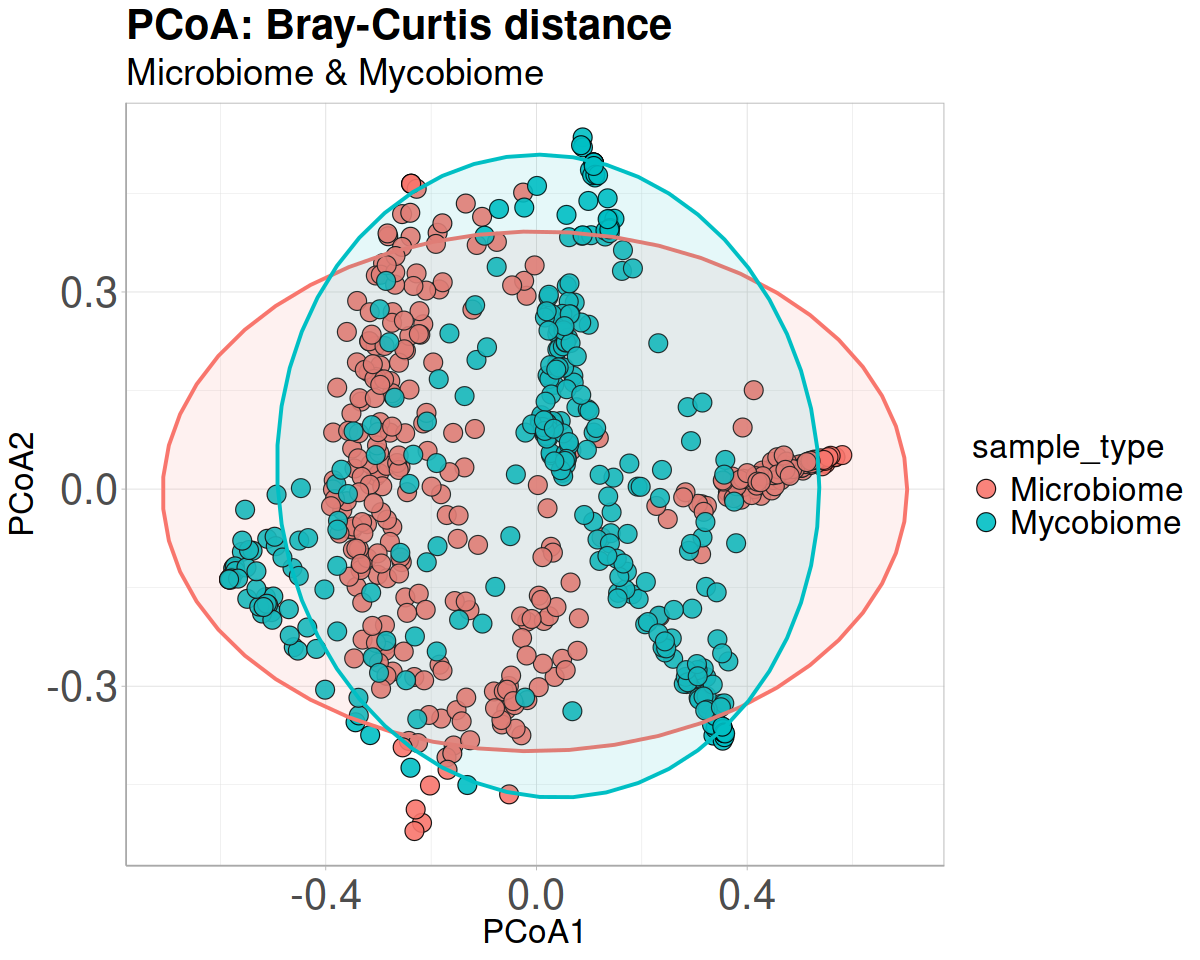

In [120]:
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates, aes(x=PCoA1, y=PCoA2)) +
# plot sample values projected on PCoA
      geom_point(aes(fill=sample_type), 
                 size = 5, alpha=0.9, pch=21) +
# plot group circles
      stat_ellipse(geom = "polygon",
                   aes(color = sample_type, 
                       fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
# add titles
      labs(
           title = "PCoA: Bray-Curtis distance", 
           subtitle = "Microbiome & Mycobiome") +
# custom plot design
      theme_light() +
      theme(axis.text=element_text(size=25),
            axis.title=element_text(size=20), 
            plot.title=element_text(size=25, face="bold"),
            plot.subtitle=element_text(size=22, face="plain"),
            plot.caption = element_text(face = "italic"),
            axis.text.x.bottom = element_text(size=25, angle=0, face='plain', hjust=0.5, vjust=0.5),
            text = element_text(size = 25), 
            legend.title=element_text(size=20),
            axis.line = element_line(color = "darkgrey"))  
pcoa_plot

In [121]:
n <- min(ncol(pcoa_res_microbiome$vectors), ncol(pcoa_res_mycobiome$vectors))
# n <- 2

procrustes_res <- procrustes(data.frame(pcoa_res_microbiome$vectors[, 1:n]), 
                             data.frame(pcoa_res_mycobiome$vectors[, 1:n]), 
                            scale=FALSE)
pcoa_rotated_mycobiome <- data.frame(procrustes_res$Yrot)
colnames(pcoa_rotated_mycobiome) <- paste0('PCoA', c(1:n))
pcoa_original_microbiome <- data.frame(procrustes_res$X)
colnames(pcoa_original_microbiome) <- paste0('PCoA', c(1:n))
pcoa_original_microbiome$sample_type <- 'Microbiome'
pcoa_rotated_mycobiome$sample_type <- 'Mycobiome'
pcoa_coordinates_procrustes <- rbind(pcoa_original_microbiome, pcoa_rotated_mycobiome)

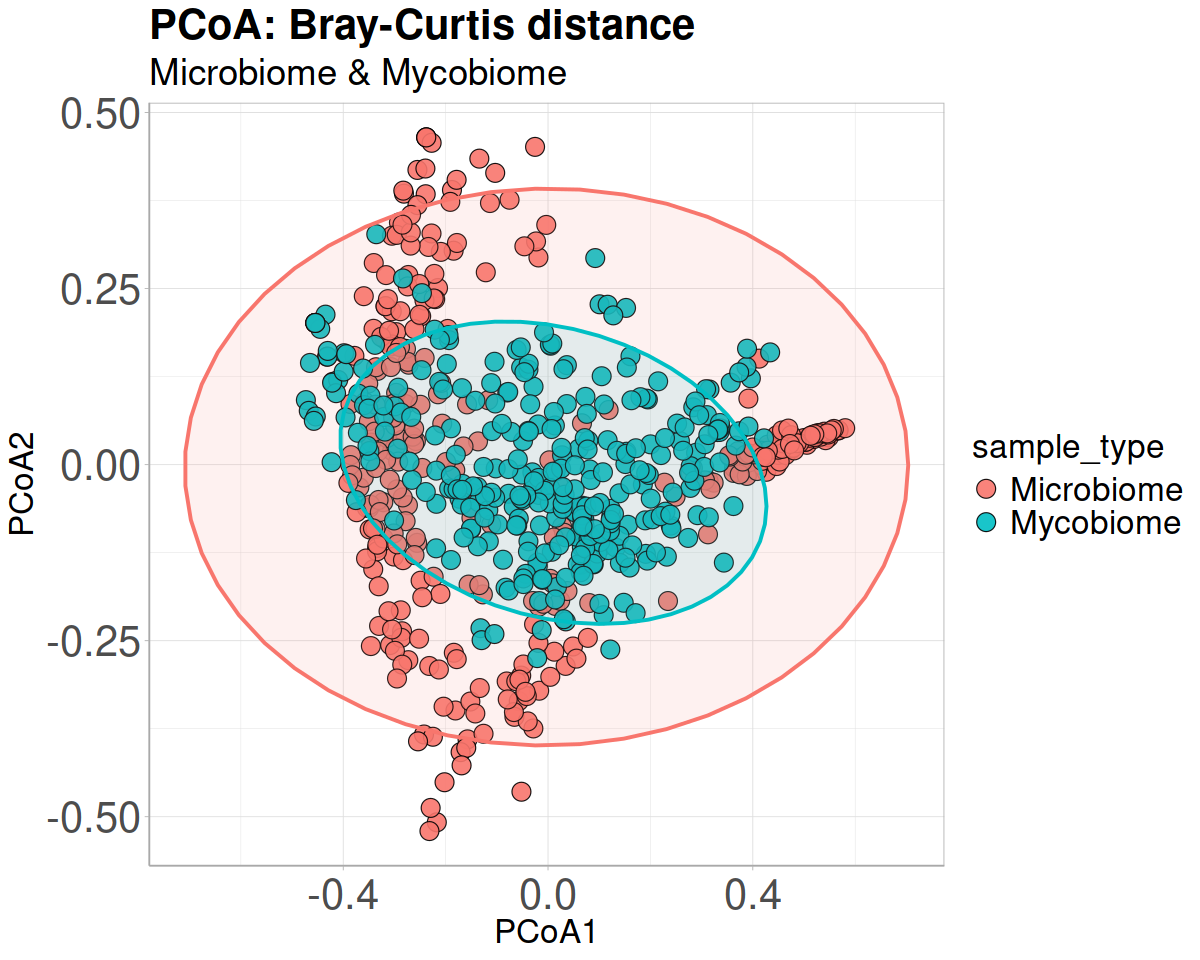

In [122]:
width = 10
height = 8
options(repr.plot.width=width, repr.plot.height=height)

pcoa_plot <- ggplot(data = pcoa_coordinates_procrustes, aes(x=PCoA1, y=PCoA2)) +
# plot sample values projected on PCoA
      geom_point(aes(fill=sample_type), 
                 size = 5, alpha=0.9, pch=21) +
# plot group circles
      stat_ellipse(geom = "polygon",
                   aes(color = sample_type, 
                       fill = after_scale(alpha(colour, 0.1))), lwd=1.1, level=0.9, show.legend = FALSE) +
# add titles
      labs(
           title = "PCoA: Bray-Curtis distance", 
           subtitle = "Microbiome & Mycobiome") +
# custom plot design
      theme_light() +
      theme(axis.text=element_text(size=25),
            axis.title=element_text(size=20), 
            plot.title=element_text(size=25, face="bold"),
            plot.subtitle=element_text(size=22, face="plain"),
            plot.caption = element_text(face = "italic"),
            axis.text.x.bottom = element_text(size=25, angle=0, face='plain', hjust=0.5, vjust=0.5),
            text = element_text(size = 25), 
            legend.title=element_text(size=20),
            axis.line = element_line(color = "darkgrey"))  
pcoa_plot

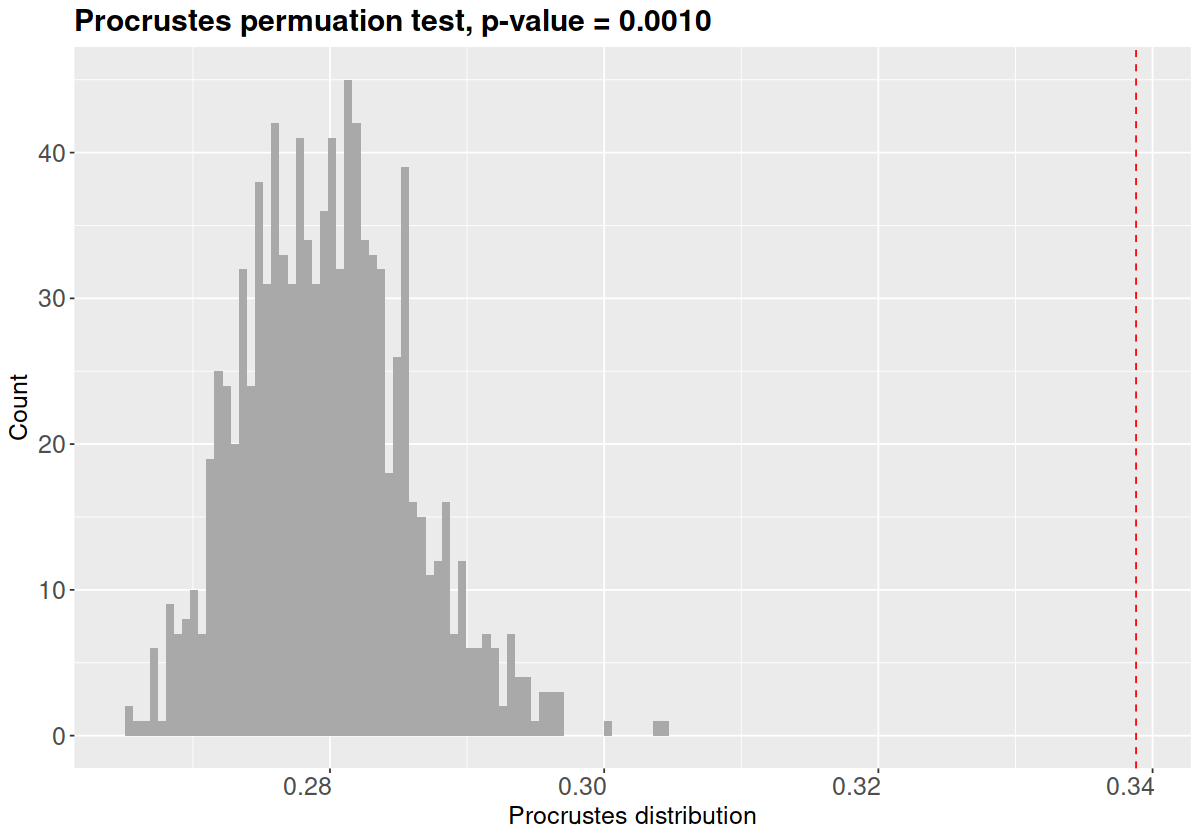

In [123]:
width = 10
height = 7
options(repr.plot.width=width, repr.plot.height=height)

n <- min(ncol(pcoa_res_microbiome$vectors), ncol(pcoa_res_mycobiome$vectors))
# n <- 2
set.seed(123)
procrustes_permutation <- protest(data.frame(pcoa_res_microbiome$vectors[, 1:n]), 
               data.frame(pcoa_res_mycobiome$vectors[, 1:n]), 
               scale=FALSE, permutations = 999)

procrustes_permutation_d <- data.frame(distances = procrustes_permutation$t)
procrustes_permutation_d0 <- procrustes_permutation$t0

procrustes_dist_plot <- ggplot(data = procrustes_permutation_d, aes(x = distances)) +
    geom_histogram(bins = 125, fill = "dark grey") +
    geom_vline(xintercept = procrustes_permutation_d0, lty = 2, color = "red") +
    labs(x = "Procrustes distribution", y = "Count") +
    theme(axis.text.x = element_text(hjust = 0.95, vjust=0.95),
          axis.text=element_text(size=15),
          axis.title=element_text(size=15),
          plot.title=element_text(size=18, face="bold")) + 
    theme(legend.position = "none") +
    ggtitle(paste0('Procrustes permuation test, p-value = ', 
                   sprintf('%.4f', procrustes_permutation$signif)))
procrustes_dist_plot

# CCA

In [ ]:
# https://github.com/blekhmanlab/host_gene_microbiome_interactions/blob/main/Tutorial/README.md

In [52]:
tune_params_grid_search <- function(X, Y, 
                                             penaltyX=seq(0.1,0.3,length=5), 
                                             penaltyY=seq(0.1,0.3,length=5)){
  num_samples <- nrow(X)
  start_time <- Sys.time()
  params <- expand.grid(c(1:length(penaltyX)), c(1:length(penaltyY)))  
  corr_demo <- mclapply(c(1:dim(params)[1]), function(x){
#   for (x in c(1:dim(params)[1])){
        i <- params[x, 'Var1']
        j <- params[x, 'Var2']
        scoreXcv <- c()
        scoreYcv <- c()
      
        score_cv <- lapply(c(1:num_samples), function(k){
            #compute weights with sample k held out:
            #Default niter = 15 edited to 5 to speed this up.
            res <- CCA(X[-k,],Y[-k,], 
                        typex="standard", typez="standard",
                       penaltyx = penaltyX[i], penaltyz = penaltyY[j], 
                       K=1, niter = 12, trace = F, standardize = T)
            ## Compute scores for k'th sample for first pair of canonical variables
            ## Take weight of features (res$u and res$v) computed using all except 
            ## the kth sample and multiple it by values for the kth sample in the 
            ## feature matrix X and Y.
            return(data.frame(k=k, scoreXcv=X[k,]%*%res$u, scoreYcv=Y[k,]%*%res$v))
      })
      score_cv <- do.call('rbind', score_cv)
      ## correlation between scores for X and Y for all held out samples.
      return(data.frame(i=i, j=j,
                        corr_demo=cor(score_cv$scoreXcv, score_cv$scoreYcv))) 
  }, mc.cores=10)
  corr_demo <- do.call('rbind', corr_demo)
  corr_demo <- dcast(corr_demo, i~j)
  row.names(corr_demo) <- corr_demo$i
  corr_demo <- corr_demo[, -1]
    
  ##identify best penalty parameters
  # find index with max absolute corr
  bestpenalty <- which(abs(corr_demo) == max(abs(corr_demo)), arr.ind = TRUE)
  bestpenaltyX <- penaltyX[bestpenalty[1]]
  bestpenaltyY <- penaltyY[bestpenalty[2]]
  
  return (c(bestpenaltyX, bestpenaltyY))
}

In [63]:
run_sparseCCA <- function(X, Z, CCA.K, penaltyX, penaltyZ){
  CCA.out <-  CCA(X,Z,typex="standard",typez="standard",K=CCA.K,
                  penaltyx=penaltyX,penaltyz=penaltyZ)
  
  ## add rownames to output factors
  rownames(CCA.out$u) <- colnames(X)
  rownames(CCA.out$v) <- colnames(Z)
  ## compute contribution of selected features to each of the samples.
  CCA_var_genes <- X %*% CCA.out$u ## canonical variance for genes 
  CCA_var_microbes <- Z %*% CCA.out$v ## canonical variance for microbes
  
  return(list(CCA.out, CCA_var_genes, CCA_var_microbes))
  
}

In [66]:
test_significance_LOOCV <- function(X, Y, num_components, bestpenaltyX, bestpenaltyY){
  cca.k = num_components
  scoresXcv <- matrix(nrow = nrow(X), ncol = cca.k)
  scoresYcv <-  matrix(nrow = nrow(Y), ncol = cca.k)
  corr_pval <- c()
  corr_r <- c()
  for(i in 1:nrow(X)){ #n = no. of samples
    #compute weights with sample i held out:
    res <- CCA(X[-i,],Y[-i,],  typex="standard", typez="standard",
               penaltyx=bestpenaltyX, penaltyz=bestpenaltyY, K=cca.k, trace = F) ## default niter = 15 which is spit out when trace = T (default)
    ###compute scores for i'th sample for each component (pair of canonical variables)
    for(j in 1:cca.k){
      scoresXcv[i,j] <- X[i,]%*%res$u[,j]
      scoresYcv[i,j] <- Y[i,]%*%res$v[,j]
    }
  }
  ## Test for each components
  for(j in 1:cca.k){
    corr <- cor.test(scoresXcv[,j],scoresYcv[,j]) ## Pearson correlation.
    corr_pval[j] <- corr$p.value
  }
  corr_pval
}

In [47]:
# filter out rarely present taxa
otu_microbiome <- data.frame(otu_table(ps_microbiome))
otu_mycobiome <- data.frame(otu_table(ps_mycobiome))
otu_microbiome <- otu_microbiome[, colSums(otu_microbiome != 0)/nrow(otu_microbiome) > 0.01]
otu_mycobiome <- otu_mycobiome[, colSums(otu_mycobiome != 0)/nrow(otu_mycobiome) > 0.01]
dim(otu_microbiome)
dim(otu_mycobiome)

[1] 335 200

[1] 335  37

In [53]:
bestPenalty <- tune_params_grid_search(as.matrix(otu_microbiome), 
                                       as.matrix(otu_mycobiome))
bestpenaltyX <- bestPenalty[1]
bestpenaltyY <- bestPenalty[2]

Using corr_demo as value column: use value.var to override.



In [65]:
cca.k = 10
cca_results <- run_sparseCCA(as.matrix(otu_microbiome), as.matrix(otu_mycobiome), 
                             cca.k, 
                             bestpenaltyX, bestpenaltyY)

123456789101112131415
12345678910
1234567891011
123456789101112
123456789101112131415
123456789101112131415
123456789101112131415
12345678910111213
123456789101112131415
123456789101112131415


In [67]:
CCA_pval <- test_significance_LOOCV(as.matrix(otu_microbiome), as.matrix(otu_mycobiome),
                                    cca.k, 
                                    bestpenaltyX, bestpenaltyY)

## adjust for multiple testing
CCA_padj <- p.adjust(CCA_pval, method = "BH")

In [74]:
# prepare data for figures
components_micorbiome <- as.data.frame(cca_results[[2]])
colnames(components_micorbiome) <- sprintf("Comp%02d", 1:cca.k)
components_micorbiome$sample <- rownames(components_micorbiome)
components_micorbiome <- pivot_longer(components_micorbiome, 
                                      cols = !sample, 
                                      names_to = "component", values_to = "Microbiome")

components_mycobiome <- as.data.frame(cca_results[[3]])
colnames(components_mycobiome) <- sprintf("Comp%02d", 1:cca.k)
components_mycobiome$sample <- rownames(components_mycobiome)
components_mycobiome <- pivot_longer(components_mycobiome, 
                                     cols = !sample, 
                                     names_to = "component", values_to = "Mycobiome")

df_comp <- cbind(components_micorbiome, components_mycobiome$Mycobiome)
df_comp <- as.data.frame(df_comp)
colnames(df_comp) <- c("sample", "component", "Microbiome", "Mycobiome")

In [97]:
coeficients_microbiome <- data.frame(cca_results[[1]]$u)
colnames(coeficients_microbiome) <- sprintf("Comp%02d", 1:cca.k)
coeficients_microbiome$taxa <- row.names(coeficients_microbiome)
coeficients_microbiome <- pivot_longer(coeficients_microbiome, 
                                     cols = !taxa, 
                                     names_to = "component", values_to = "coefficient")
coeficients_microbiome <- coeficients_microbiome[coeficients_microbiome$coefficient != 0, ]

coeficients_mycobiome <- data.frame(cca_results[[1]]$v)
colnames(coeficients_mycobiome) <- sprintf("Comp%02d", 1:cca.k)
coeficients_mycobiome$taxa <- row.names(coeficients_mycobiome)
coeficients_mycobiome <- pivot_longer(coeficients_mycobiome, 
                                     cols = !taxa, 
                                     names_to = "component", values_to = "coefficient")
coeficients_mycobiome <- coeficients_mycobiome[coeficients_mycobiome$coefficient != 0, ]

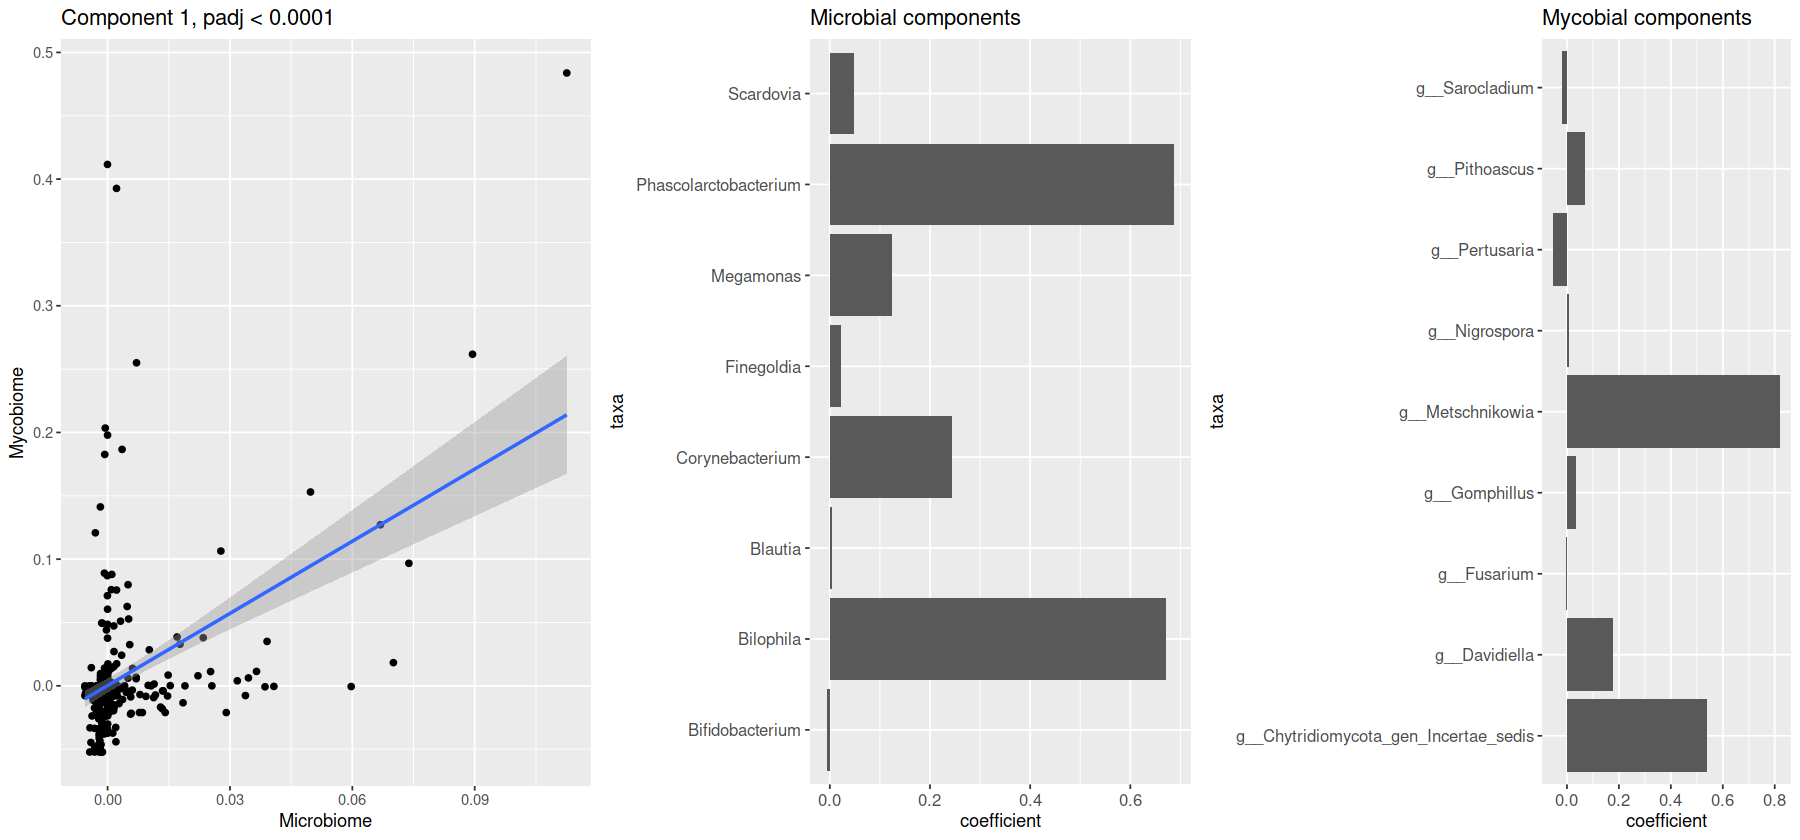

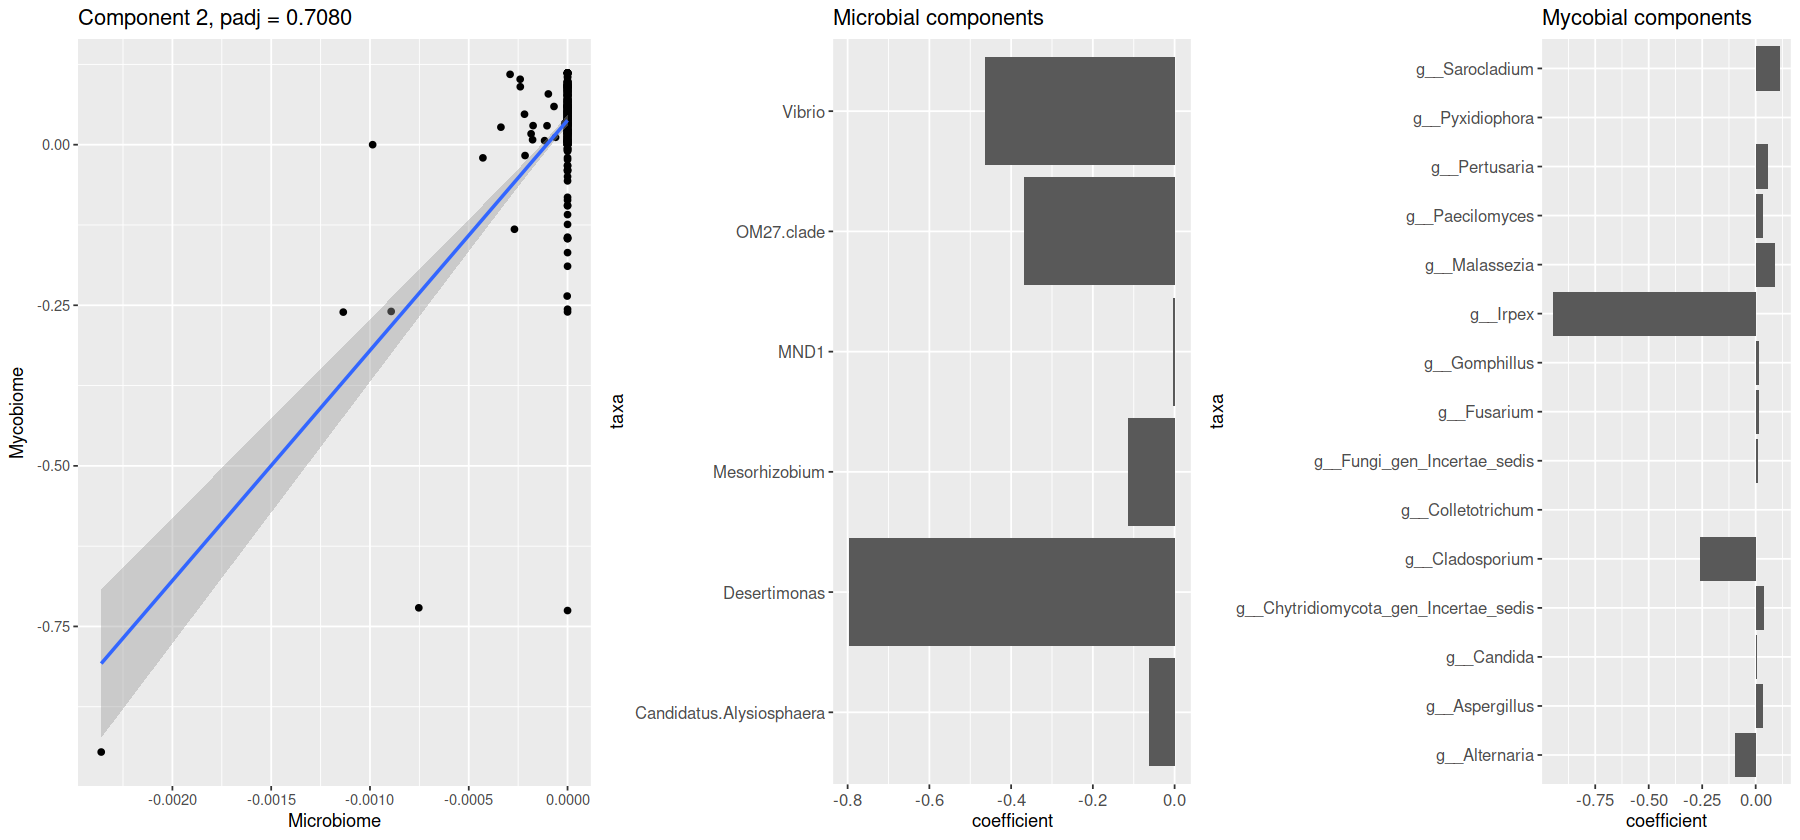

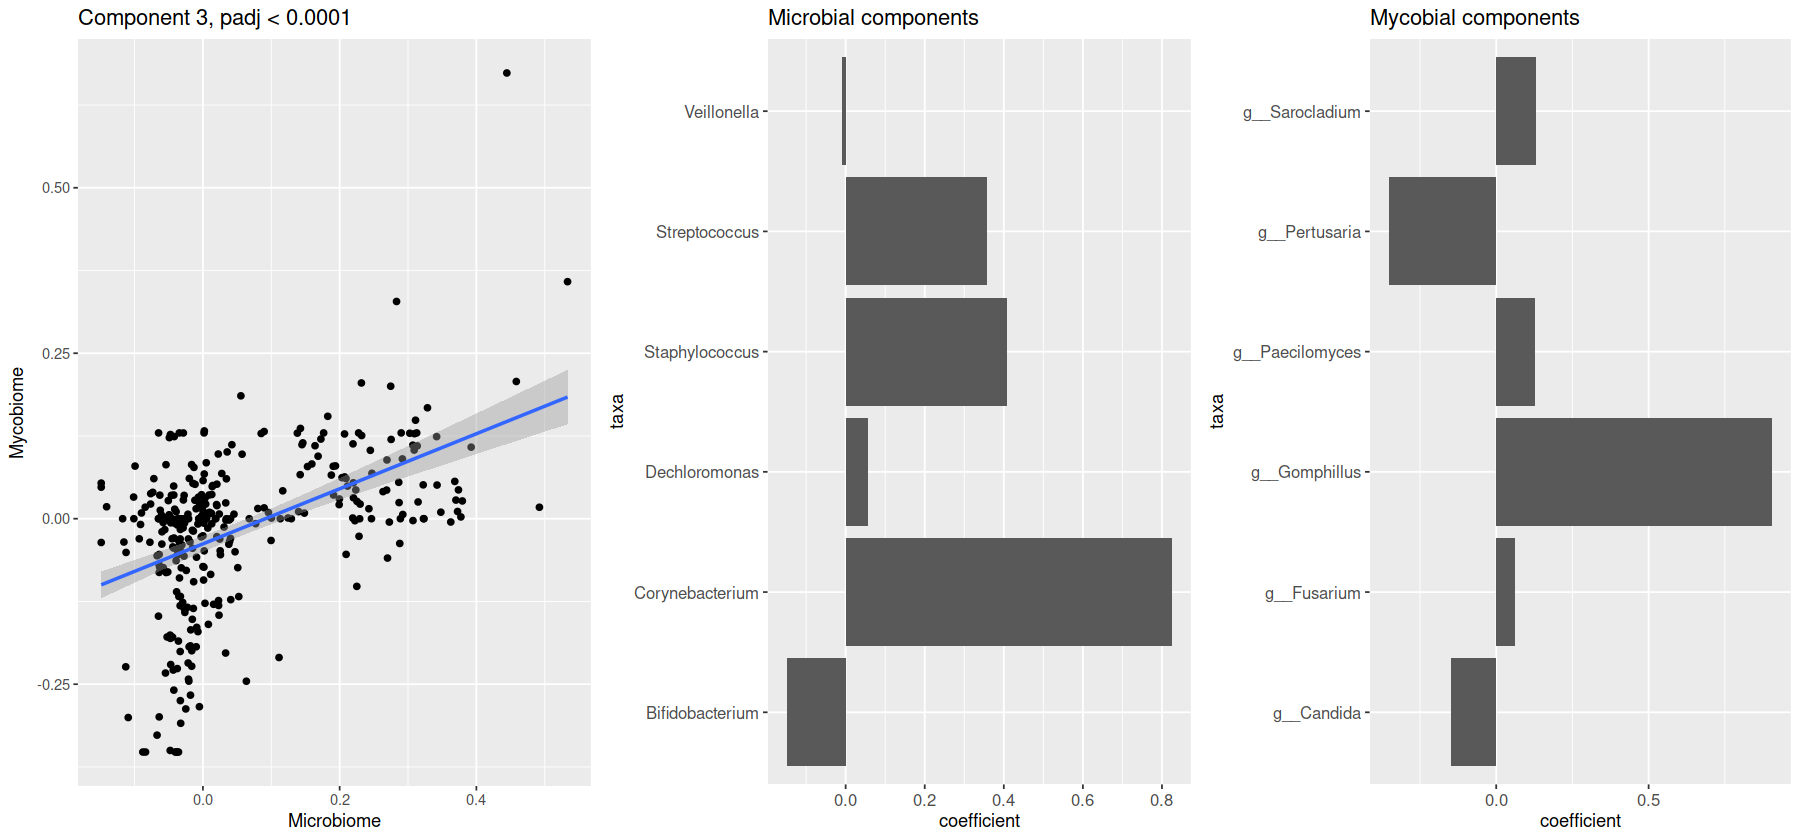

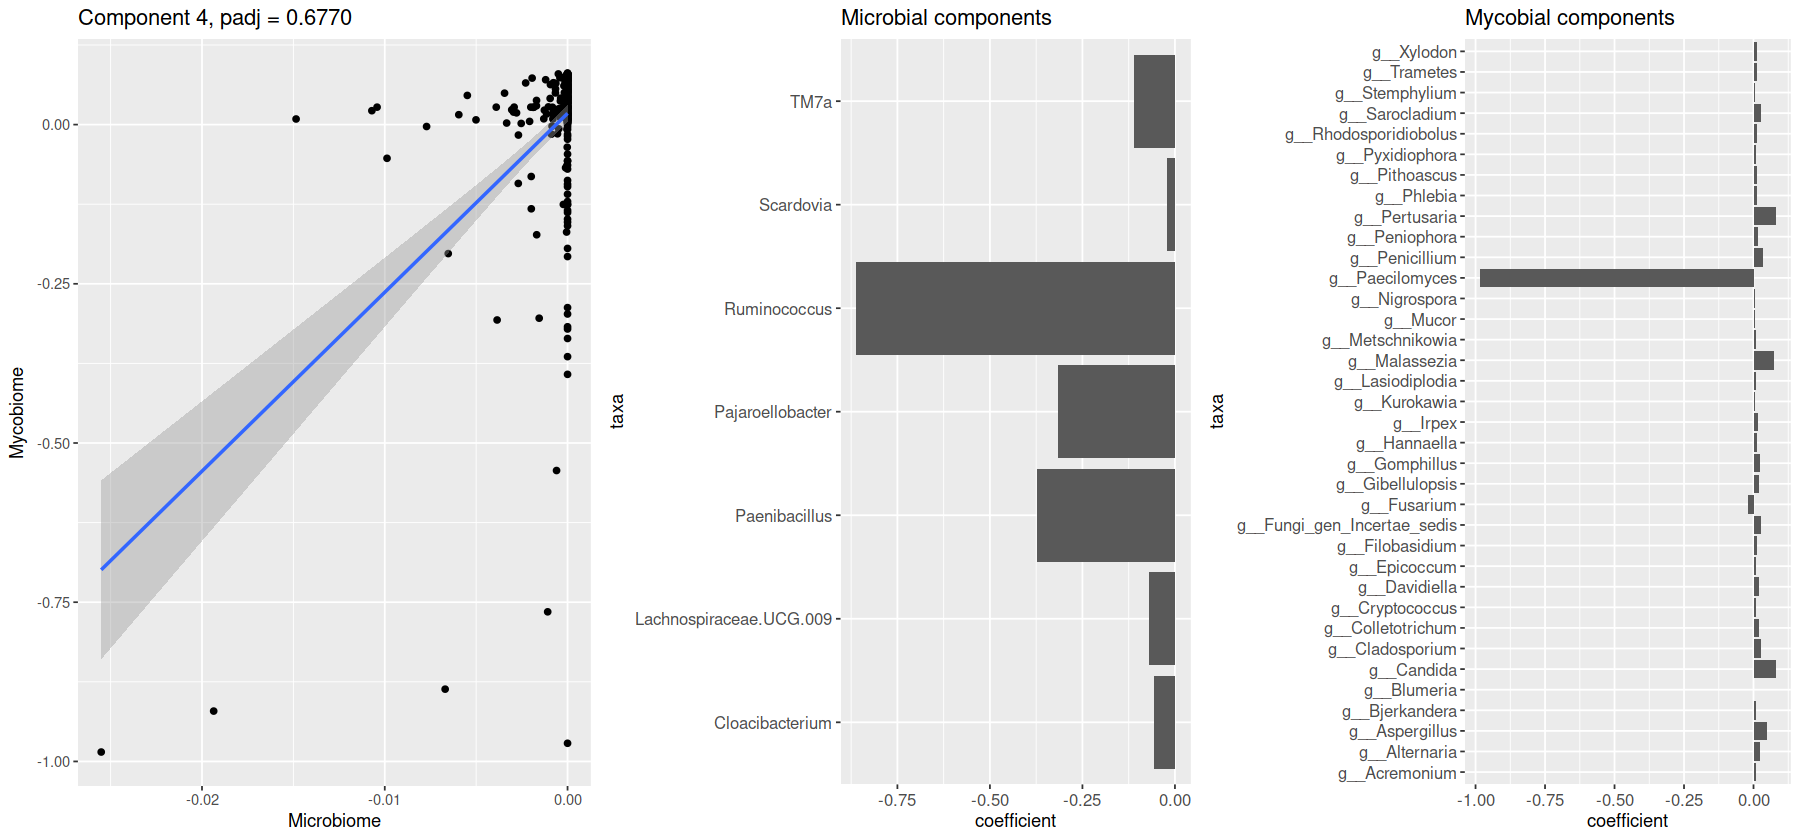

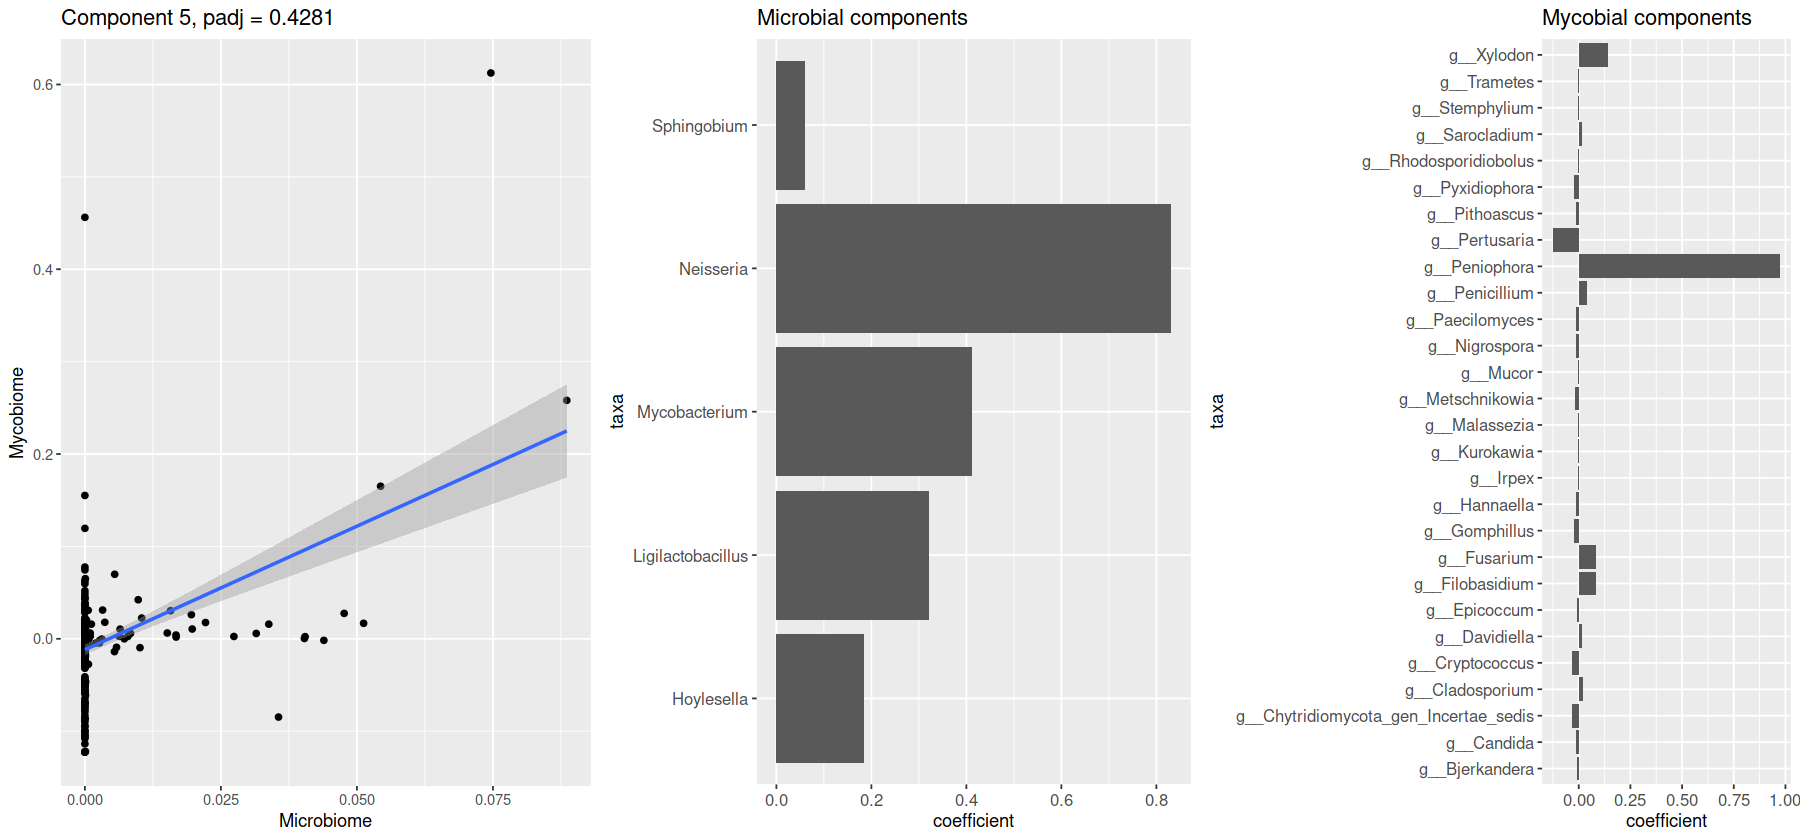

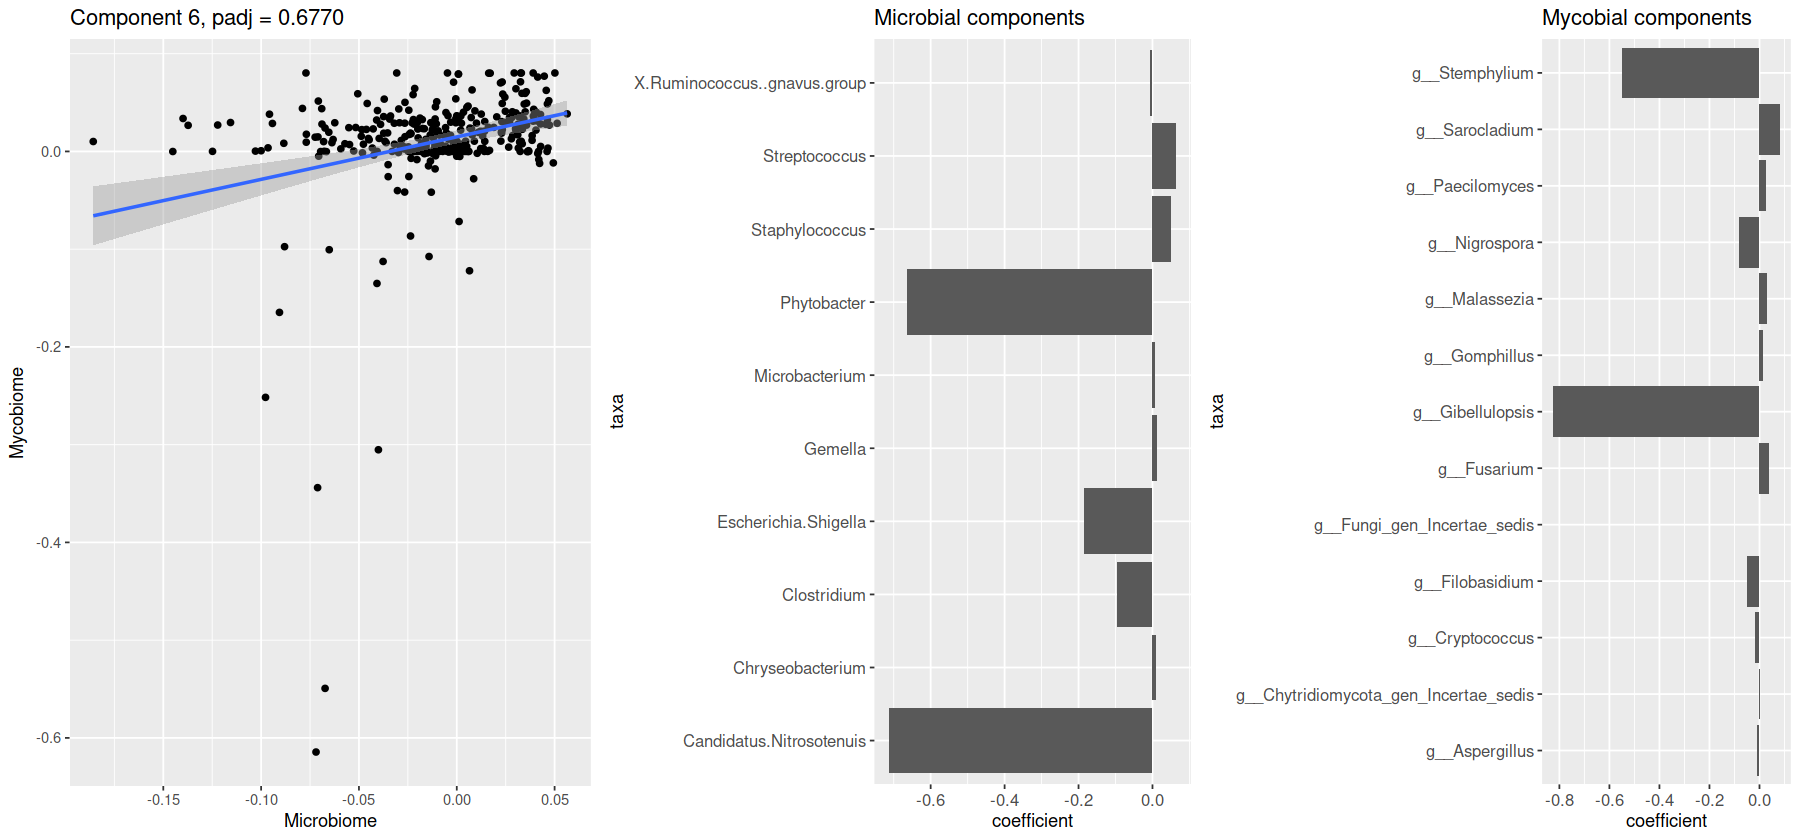

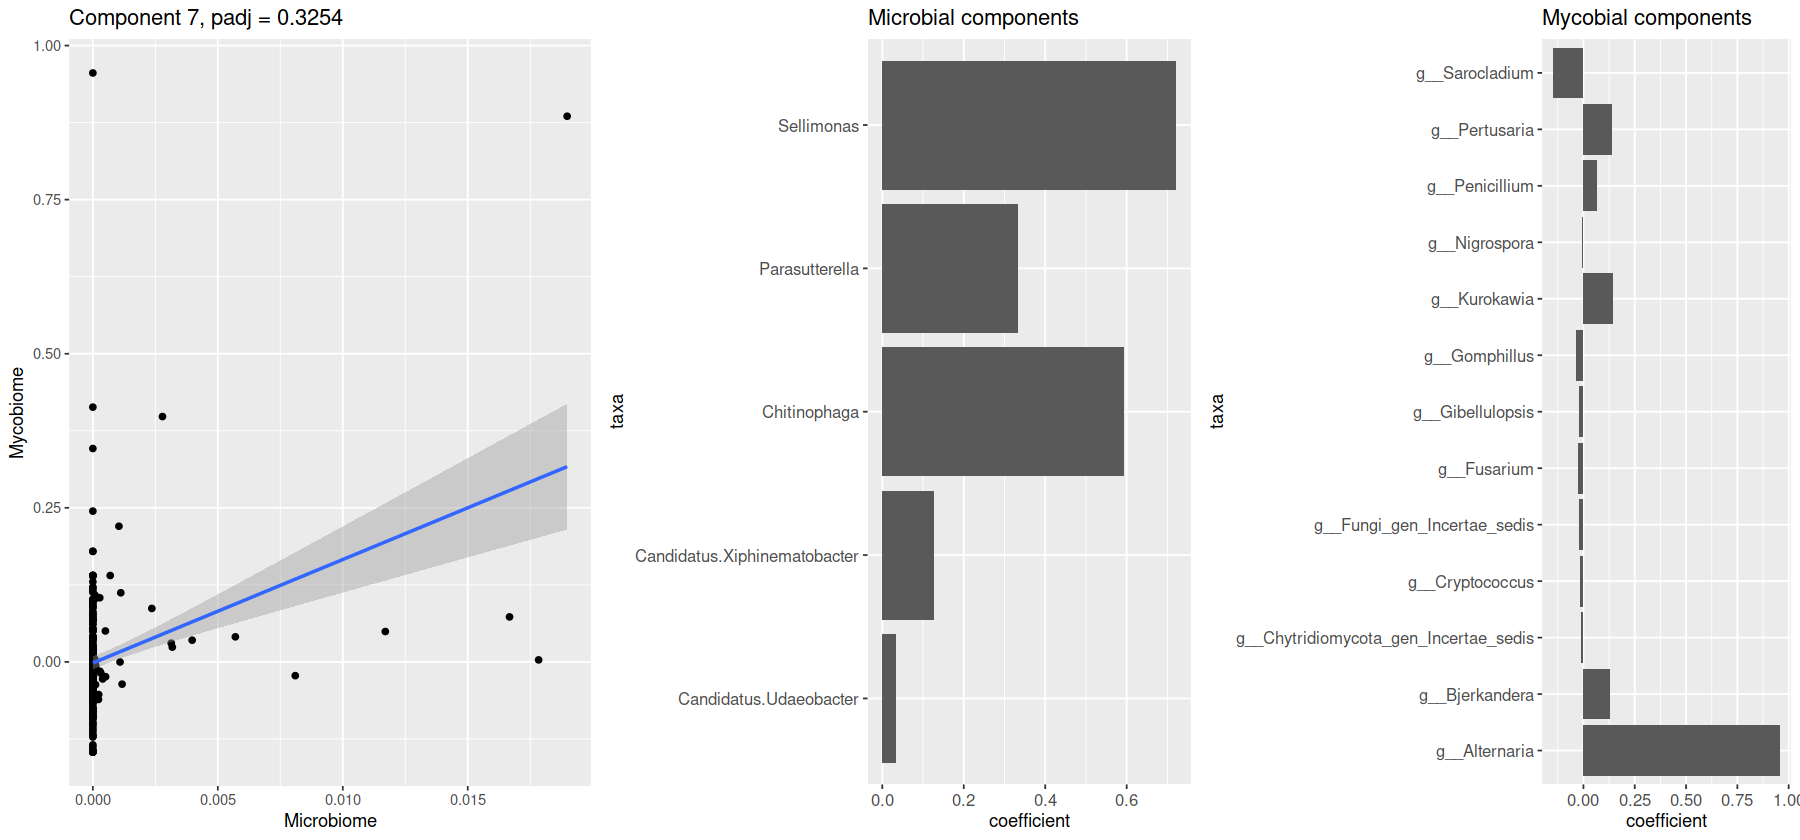

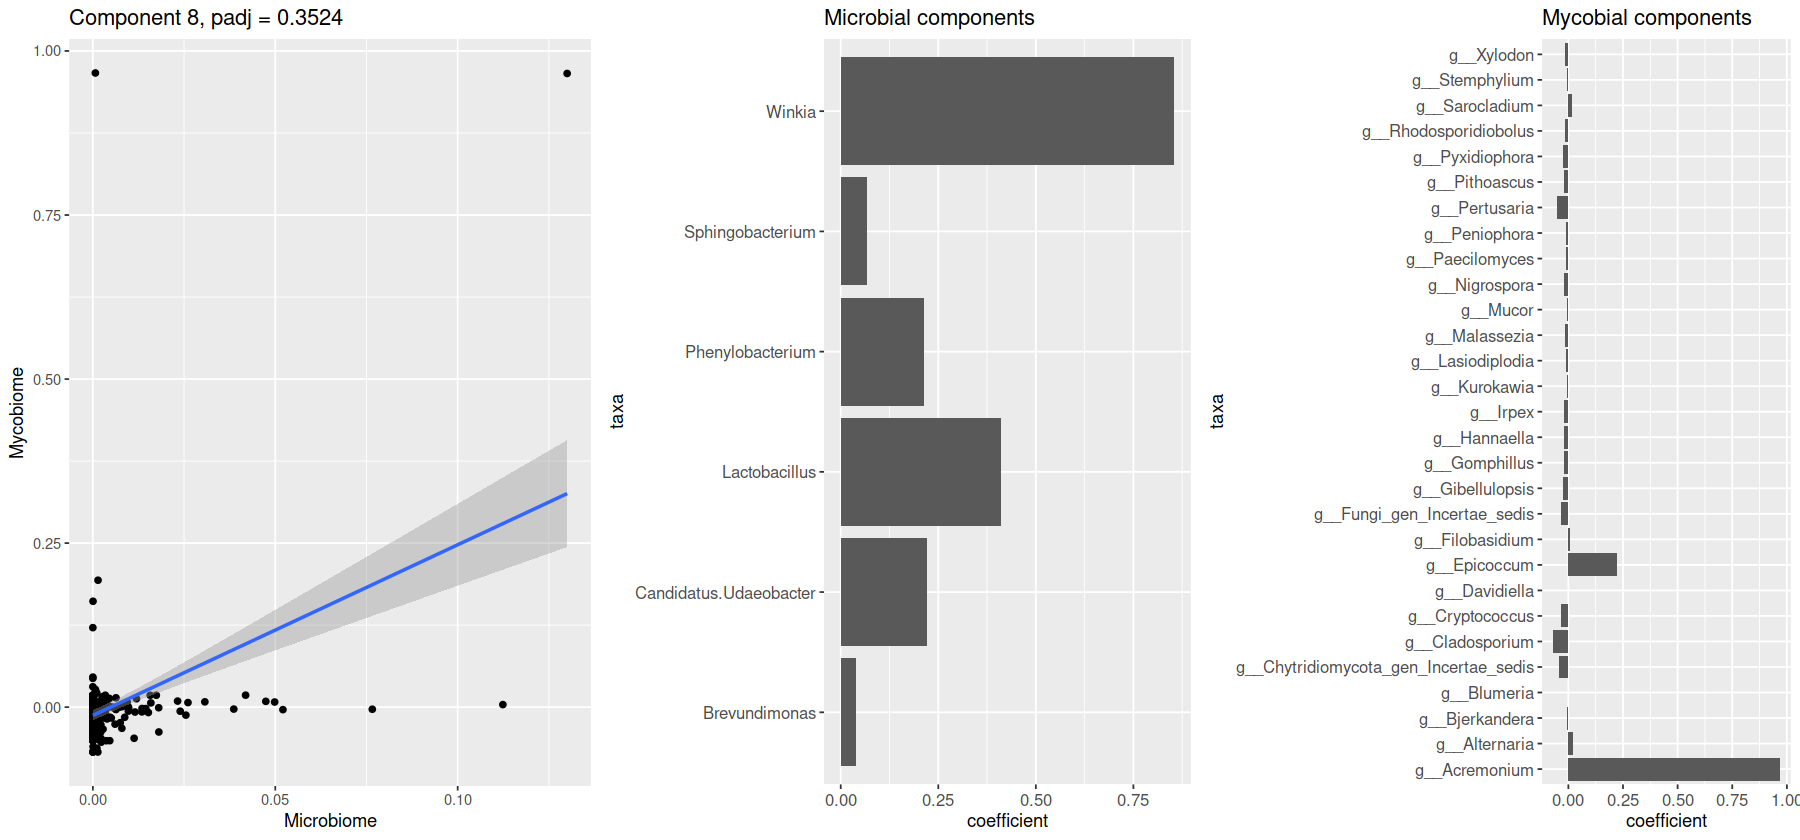

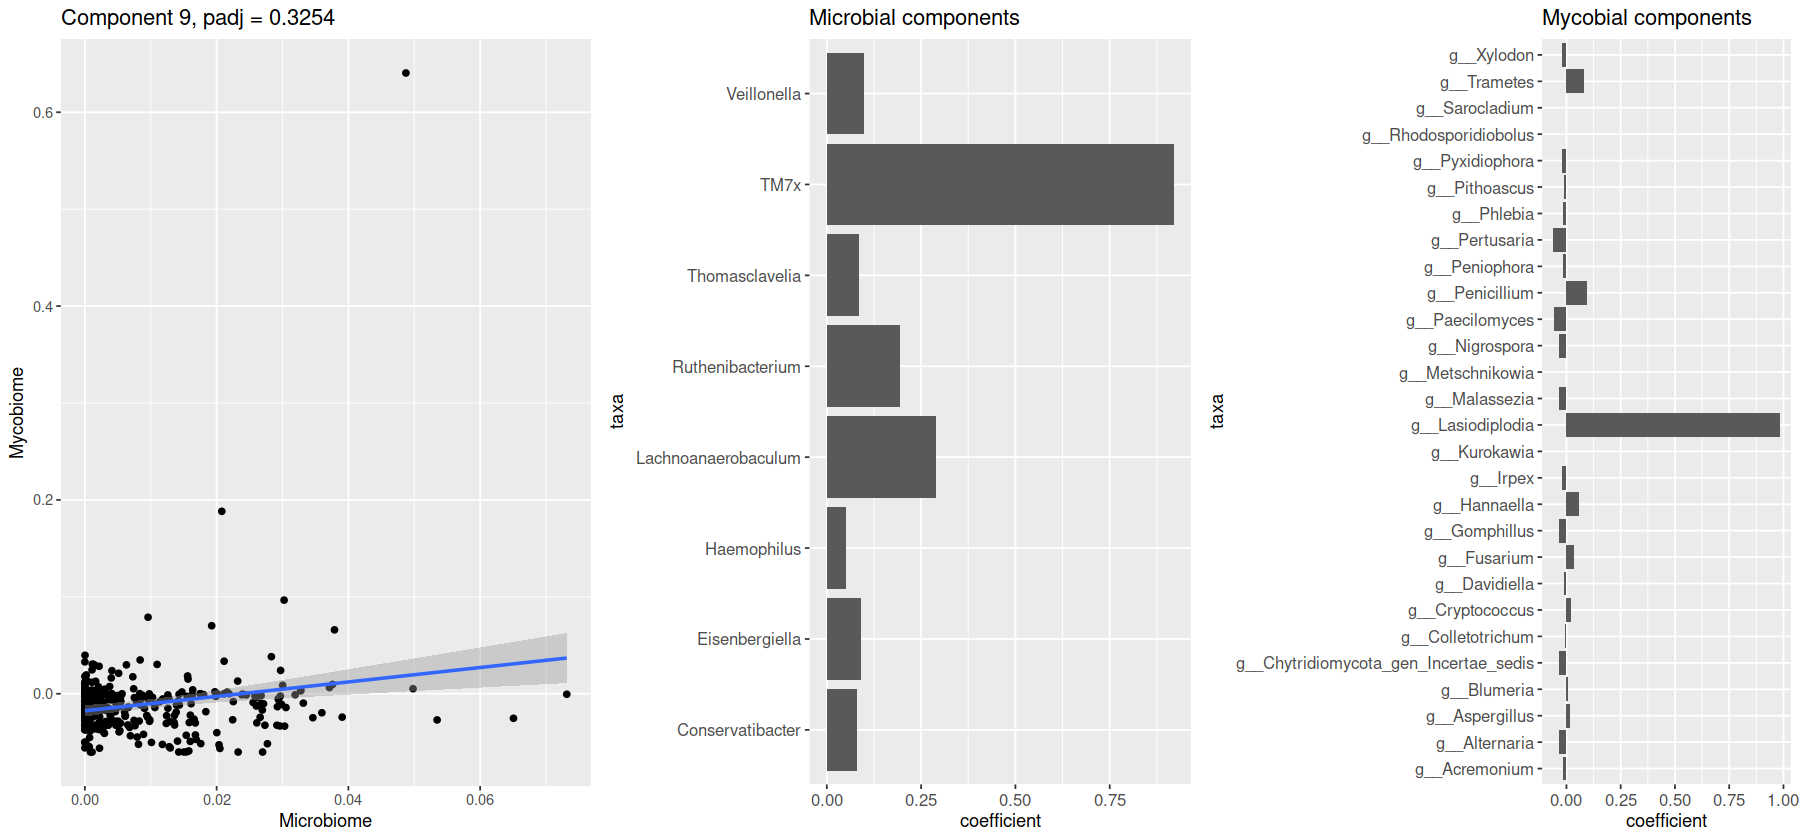

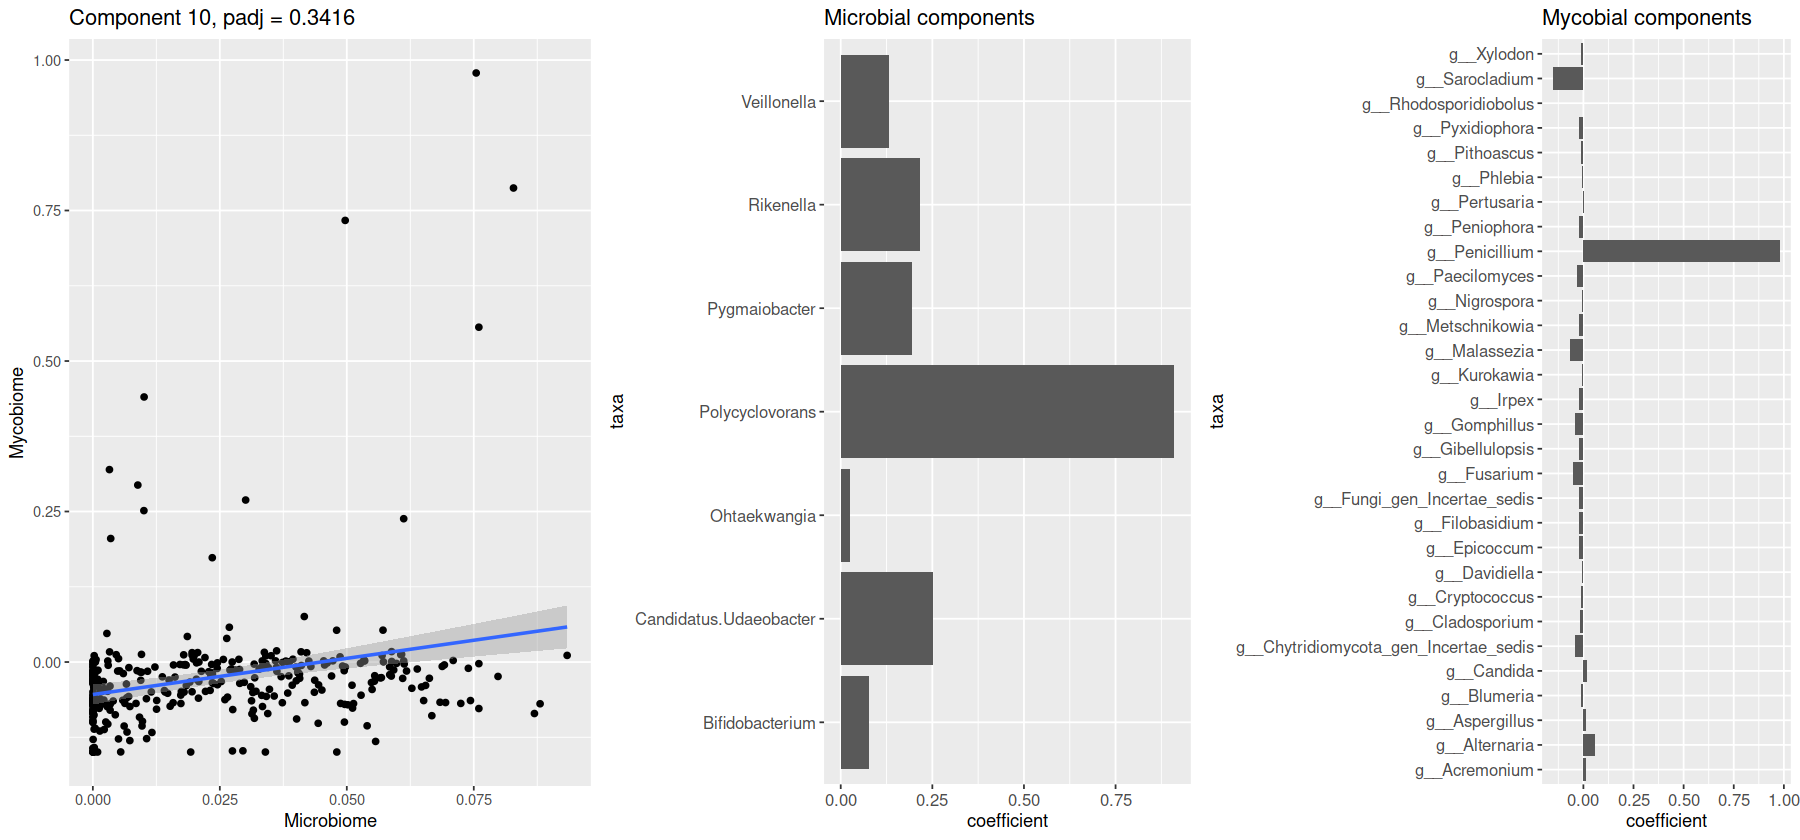

In [116]:
width = 15
height = 7
options(repr.plot.width=width, repr.plot.height=height)

for (k in c(1:cca.k)){
    df_comp_subset <- df_comp[df_comp$component == sprintf("Comp%02d", k), ]
    coeficients_microbiome_subset <- coeficients_microbiome[coeficients_microbiome$component == sprintf("Comp%02d", k), ]
    coeficients_mycobiome_subset <- coeficients_mycobiome[coeficients_mycobiome$component == sprintf("Comp%02d", k), ]
    if (CCA_padj[k] < 0.0001){
        padj <- "< 0.0001"
    } else {
        padj <- sprintf("= %.4f", CCA_padj[k])
    }
    
    plot_cca <- ggplot(df_comp_subset, aes(x = Microbiome, y = Mycobiome)) +
                  geom_point() +
                  geom_smooth(method='lm', formula= y~x) +
                  ggtitle(paste0('Component ', k, ', padj ', padj))
    plot_microbiome <- ggplot(coeficients_microbiome_subset, aes(x = coefficient, y = taxa)) +
              geom_bar(stat='identity') +
              theme(axis.text=element_text(size=10)) +
              ggtitle("Microbial components")
    plot_mycobiome <- ggplot(coeficients_mycobiome_subset, aes(x = coefficient, y = taxa)) +
              geom_bar(stat='identity')  +
              theme(axis.text=element_text(size=10))+
              ggtitle("Mycobial components")
    
    # compbine figures together
    p <- ggarrange(plot_cca, plot_microbiome, plot_mycobiome,
              ncol = 3, nrow = 1, #align = "hv", 
              common.legend = FALSE, legend = "bottom") 
    print(p)
    
}